# Running The 3 Architectures on Fashion MNIST

# All CNN Experiments Performed using Google Colab's T4 GPU

In [1]:
!git clone https://github.com/henrybattley/neurons-as-autoencoders.git

Cloning into 'neurons-as-autoencoders'...
remote: Enumerating objects: 1317, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (59/59), done.
remote: Total 1317 (delta 58), reused 51 (delta 29), pack-reused 1229 (from 1)
Receiving objects: 100% (1317/1317), 3.76 MiB | 6.18 MiB/s, done.
Resolving deltas: 100% (1006/1006), done.


In [2]:
%cd neurons-as-autoencoders
!git pull

/content/neurons-as-autoencoders
Already up to date.


In [3]:
import sys
import os
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [4]:
import random
import numpy as np
import pandas as pd
import torch, torchvision
import torch.nn as nn
from torchsummary import summary
import importlib
import matplotlib.pyplot as plt

# Get Data

In [5]:
# getting data
print("Loading Fashion MNIST dataset...")
fmnist_raw = torchvision.datasets.FashionMNIST(
    root="./data",
    train=True,
    download=True,
)

#dataset to a GPU-ready float tensor 
# Extract raw PIL data (.data is a 60000x28x28 unit8 tensor)
fmnist_images = fmnist_raw.data.float() / 255.0  # Scale to [0.0, 1.0]
fmnist_images = fmnist_images.unsqueeze(1)        # Shape becomes (60000, 1, 28, 28)
fmnist_labels = fmnist_raw.targets                # Shape (60000,)

#TensorDataset
fmnist = torch.utils.data.TensorDataset(fmnist_images, fmnist_labels)

Loading Fashion MNIST dataset...


100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 203kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 24.5MB/s]


# Standard CNN Model

In [6]:
#get model
from src.models import cnn_model

#get experiment
from src.experiments import cnn_experiments

In [28]:
all_train_histories = []
all_train_accuracies = []

peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = cnn_experiments.train_cnn_get_features(
        fmnist,
        input_dims=28,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_train_histories.append(training_history["train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Training Loss: 0.5577, Training Accuracy: 81.11
Epoch [2/100], Training Loss: 0.3704, Training Accuracy: 87.16
Epoch [3/100], Training Loss: 0.3348, Training Accuracy: 88.33
Epoch [4/100], Training Loss: 0.3132, Training Accuracy: 89.10
Epoch [5/100], Training Loss: 0.2976, Training Accuracy: 89.64
Epoch [6/100], Training Loss: 0.2844, Training Accuracy: 90.03
Epoch [7/100], Training Loss: 0.2745, Training Accuracy: 90.30
Epoch [8/100], Training Loss: 0.2657, Training Accuracy: 90.70
Epoch [9/100], Training Loss: 0.2586, Training Accuracy: 90.94
Epoch [10/100], Training Loss: 0.2518, Training Accuracy: 91.19
Epoch [11/100], Training Loss: 0.2462, Training Accuracy: 91.33
Epoch [12/100], Training Loss: 0.2388, Training Accuracy: 91.63
Epoch [13/100], Training Loss: 0.2350, Training Accuracy: 91.82
Epoch [14/100], Training Loss: 0.2291, Training Accuracy: 92.01
Epoch [15/100], Training Loss: 0.2259, Training Accuracy: 91.99
Epoch [16/100], Trai

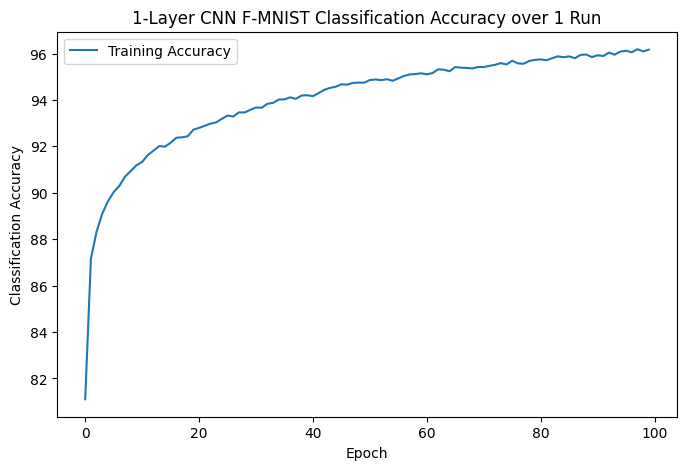

In [30]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")



plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("1-Layer CNN F-MNIST Classification Accuracy over 1 Run")
plt.show()

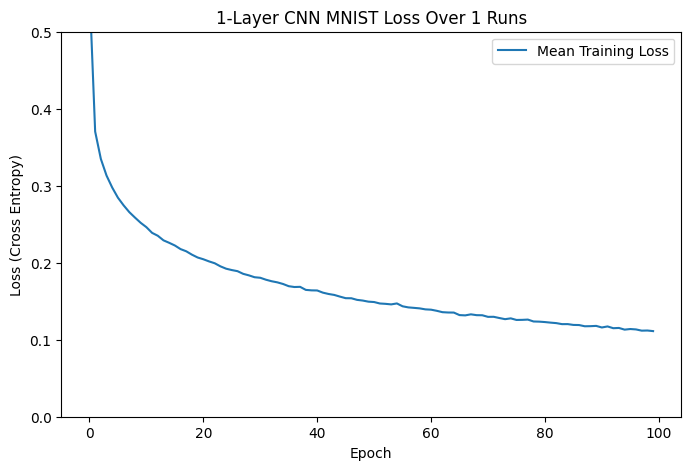

In [31]:
epochs = np.arange(len(training_history["train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_loss"],label="Mean Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
plt.ylim(0,0.5)
plt.title("1-Layer CNN MNIST Loss Over 1 Runs")
plt.show()

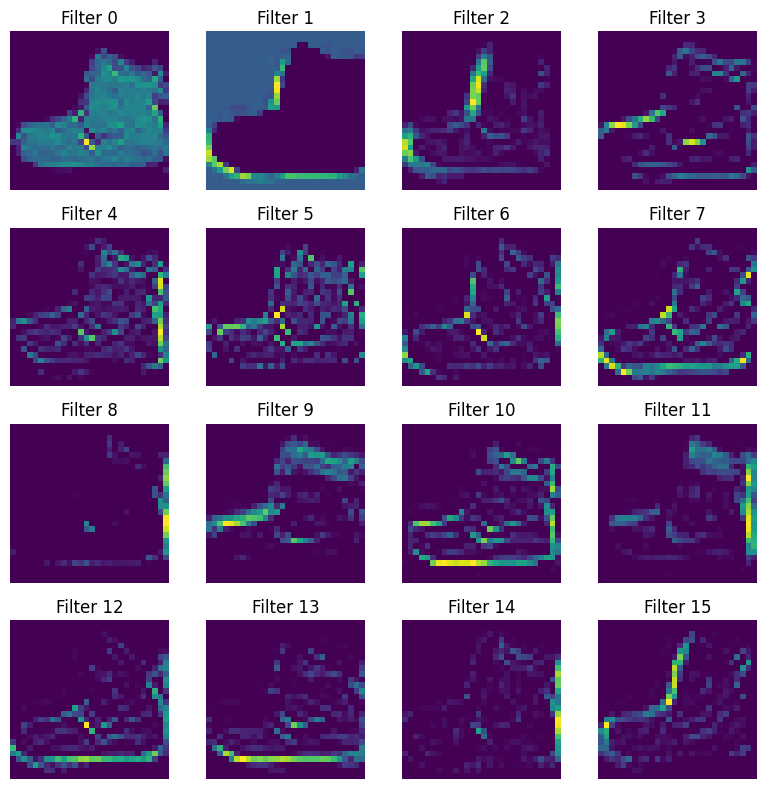

In [33]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

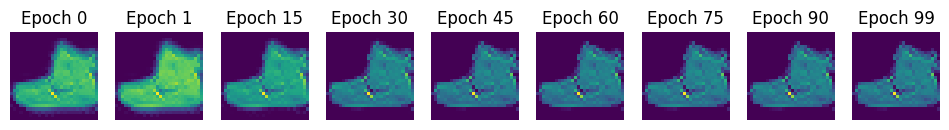

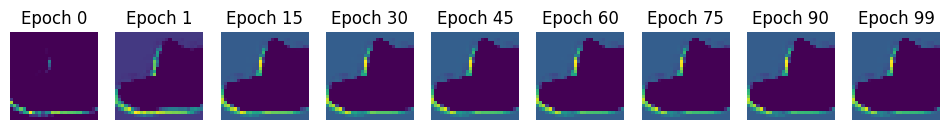

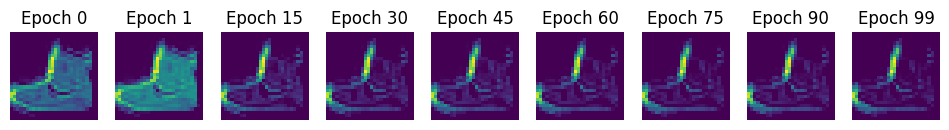

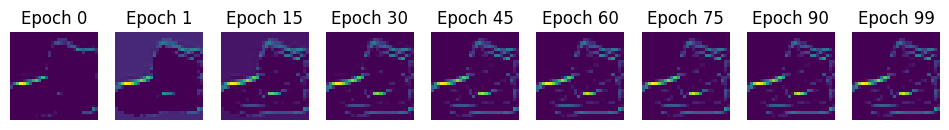

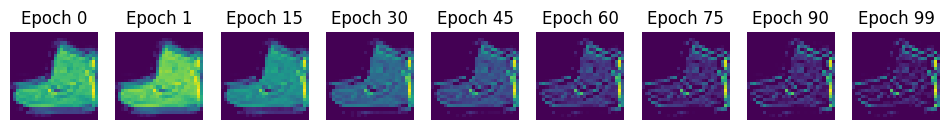

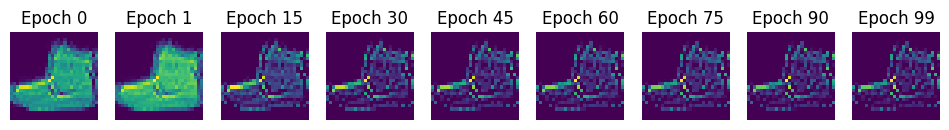

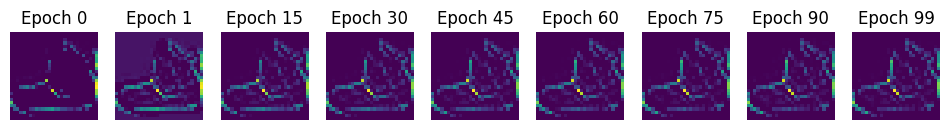

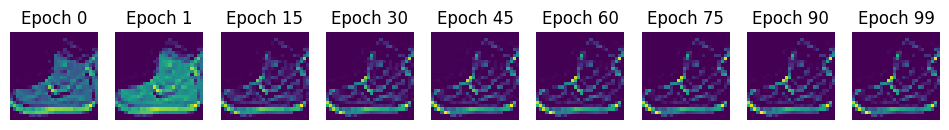

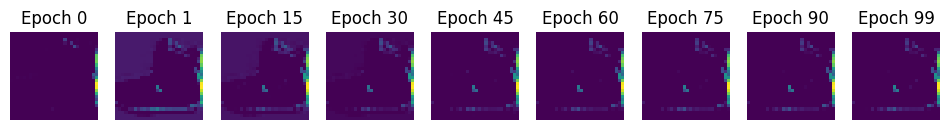

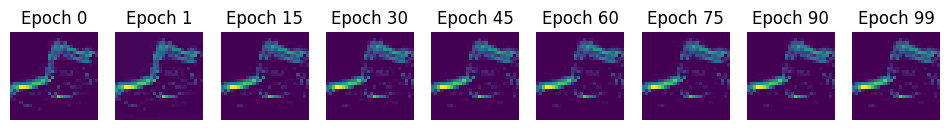

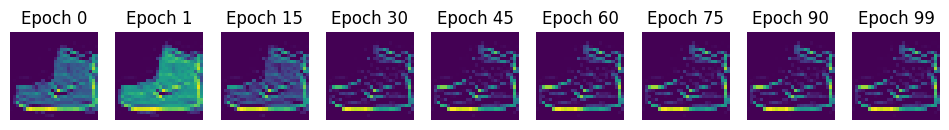

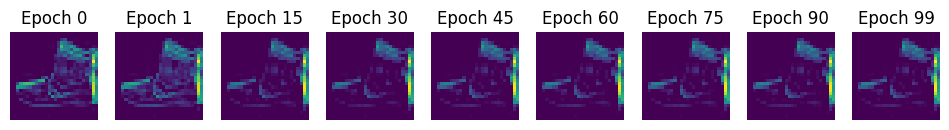

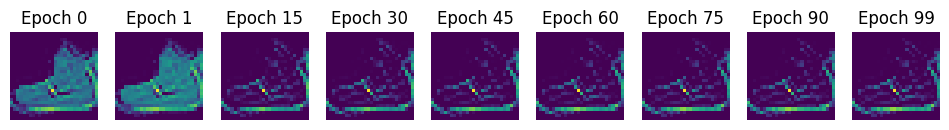

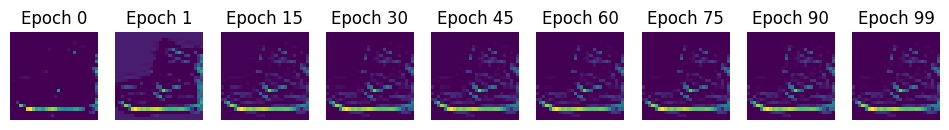

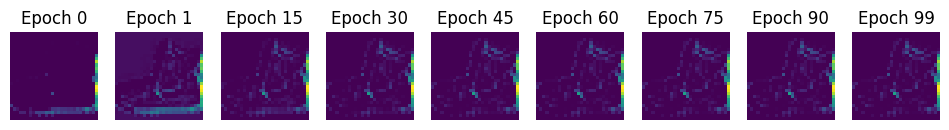

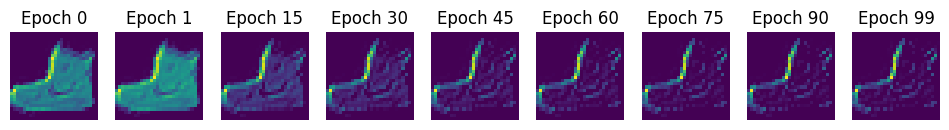

In [35]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))


    for ax, epoch in zip(axes, epochs):

        fmap = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(fmap,cmap="viridis")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [36]:
import torch.nn.functional as F 
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.5004)
tensor(0.8970)


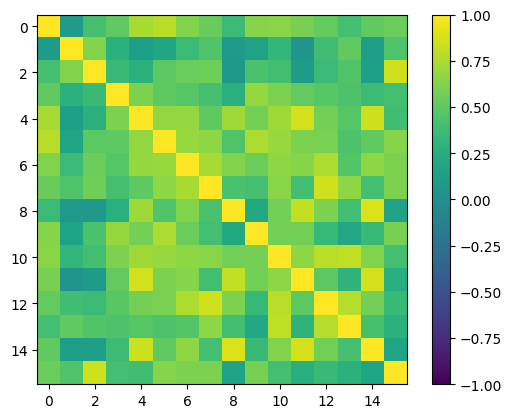

In [37]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

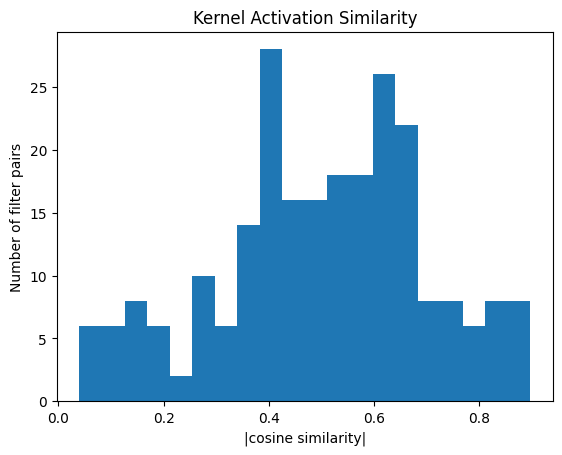

In [38]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Kernels

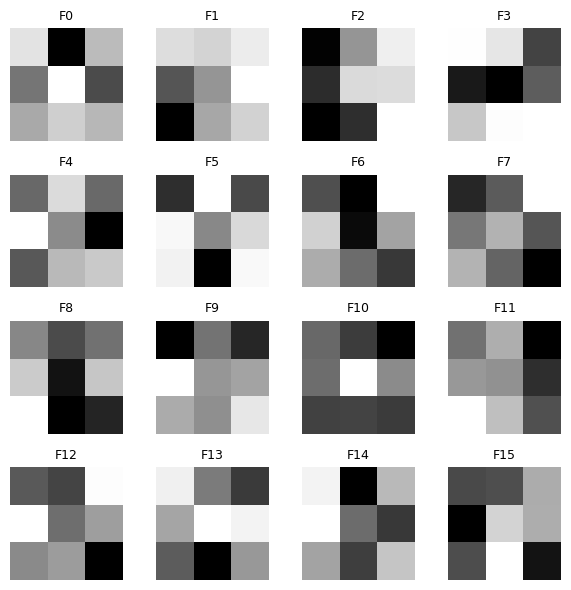

In [40]:

weights = feature_history[99]["kernel_weights"]


fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    kernel = weights[i, 0]         
    ax.imshow(kernel, cmap="gray")
    ax.set_title(f"F{i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

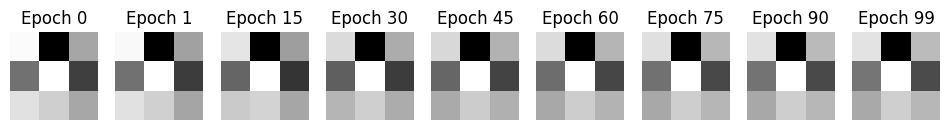

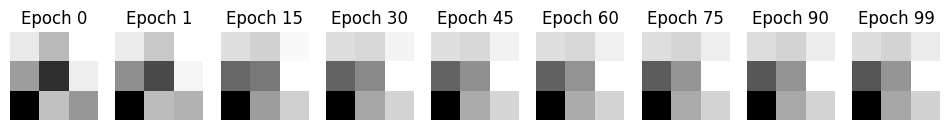

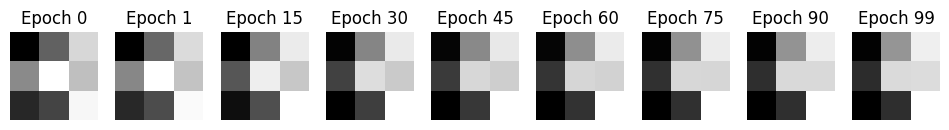

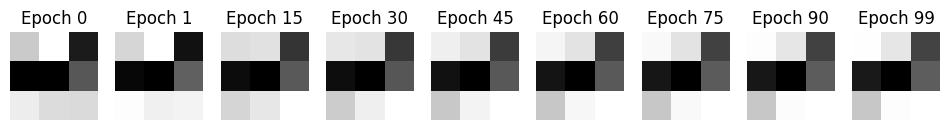

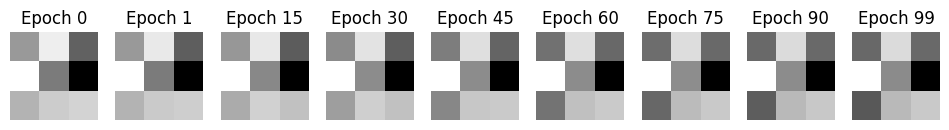

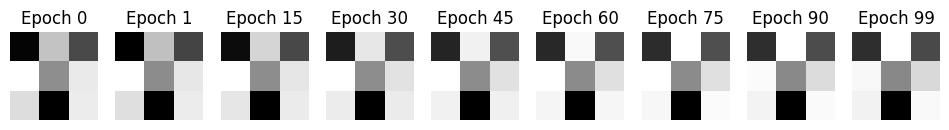

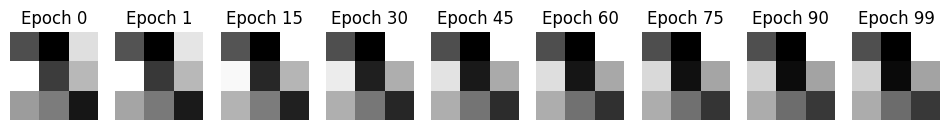

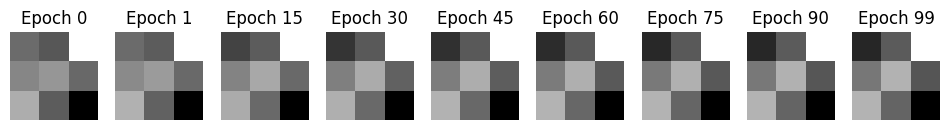

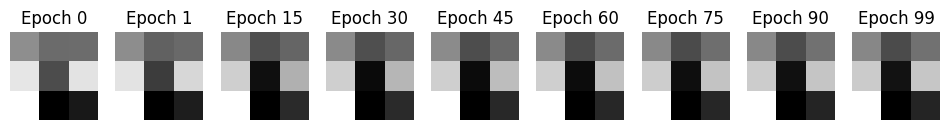

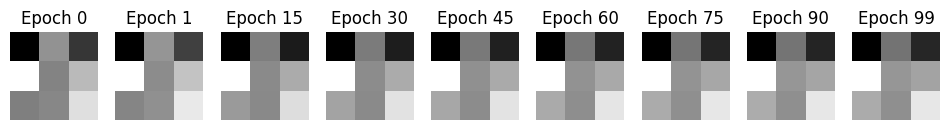

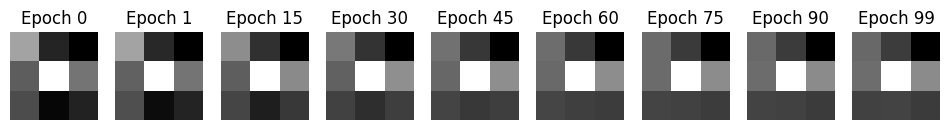

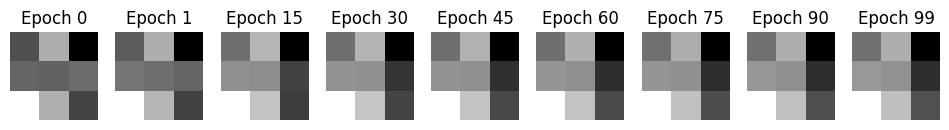

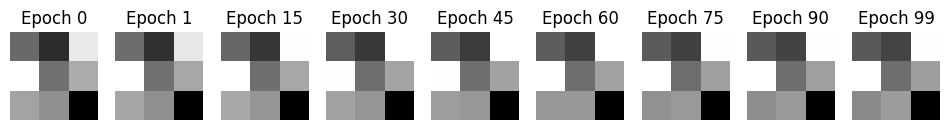

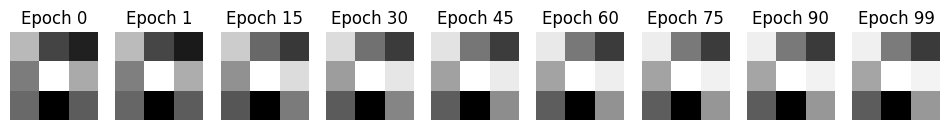

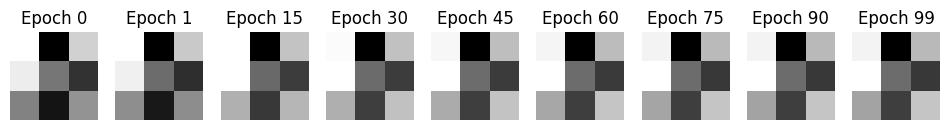

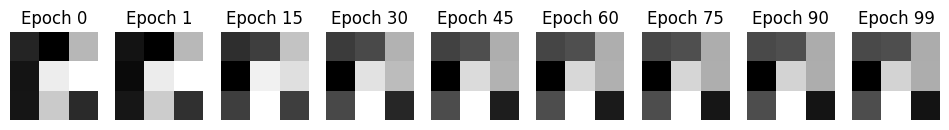

In [41]:
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))

    for ax, epoch in zip(axes, epochs):

        weights = feature_history[epoch]["kernel_weights"][filter_idx,0]

        #kernel = weights[i, 0] 
        
        ax.imshow(weights,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [42]:
conv_weights = model.conv1.weight.flatten(1)

conv_weights = F.normalize(conv_weights, dim=1)

similarity_matrix = conv_weights @ conv_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=conv_weights.device)


mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.2567
Mean filter cosine similarity: -0.0368
Maximum filter similarity: 0.8298
Minimum filter similarity: -0.7060


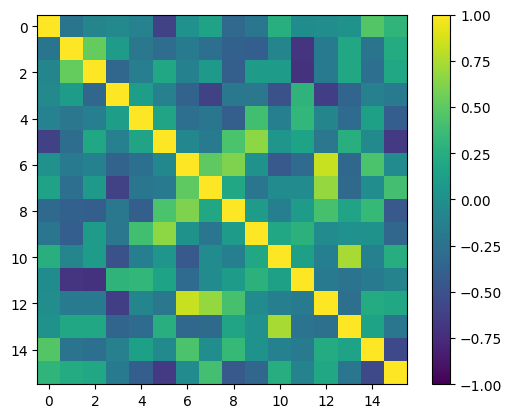

In [43]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

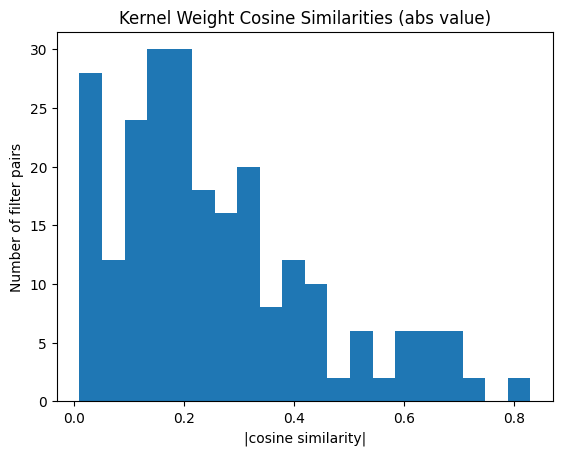

In [44]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Convolutional Autoencoder

### Initial model

In [9]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation


    
    model, training_history,feature_hist, elapsed = cnn_experiments.train_ae_cnn_get_features(
        fmnist,
        input_dims=28,
        in_channels=1,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        bias=True,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

device is: cuda
Epoch [1/100], Encoder Loss: 0.0514
Epoch [1/100], Training Loss: 0.5838, Training Accuracy: 80.03
Epoch [2/100], Encoder Loss: 0.0033
Epoch [2/100], Training Loss: 0.4049, Training Accuracy: 85.74
Epoch [3/100], Encoder Loss: 0.0015
Epoch [3/100], Training Loss: 0.3719, Training Accuracy: 87.01
Epoch [4/100], Encoder Loss: 0.0011
Epoch [4/100], Training Loss: 0.3547, Training Accuracy: 87.51
Epoch [5/100], Encoder Loss: 0.0009
Epoch [5/100], Training Loss: 0.3407, Training Accuracy: 87.98
Epoch [6/100], Encoder Loss: 0.0008
Epoch [6/100], Training Loss: 0.3310, Training Accuracy: 88.19
Epoch [7/100], Encoder Loss: 0.0007
Epoch [7/100], Training Loss: 0.3267, Training Accuracy: 88.23
Epoch [8/100], Encoder Loss: 0.0007
Epoch [8/100], Training Loss: 0.3143, Training Accuracy: 88.78
Epoch [9/100], Encoder Loss: 0.0006
Epoch [9/100], Training Loss: 0.3086, Training Accuracy: 88.89
Epoch [10/100], Encoder Loss: 0.0006
Epoch [10/100], Training Loss: 0.3063, Training Accuracy

average over final 10 epochs for seed =0

In [10]:
91.26+91.35+91.23+91.12+90.89+91.23+91.19+90.97+90.80+90.78

910.8199999999999

# Omitting bias and weight tying

In [7]:
all_train_histories = []
all_train_accuracies = []
all_encoder_histories = []


peak_memory =[]
run_times= []

for seed in range(1): # just 1 run
    #run training and evaluation

    print(f"model run: {seed}")

    
    model, training_history,feature_hist, elapsed = cnn_experiments.train_ae_cnn_weight_tie_get_features(
        fmnist,
        input_dims=28,
        in_channels=1,
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        bias=False,
        seed=seed 
    )


    all_train_histories.append(training_history["task_train_loss"])
    all_train_accuracies.append(training_history["train_accuracy"])
    all_encoder_histories.append(training_history["encoder_train_loss"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Loss: 0.1347
Epoch [1/100], Training Loss: 0.6155, Training Accuracy: 80.04
Epoch [2/100], Encoder Loss: 0.1110
Epoch [2/100], Training Loss: 0.4025, Training Accuracy: 86.44
Epoch [3/100], Encoder Loss: 0.1069
Epoch [3/100], Training Loss: 0.3638, Training Accuracy: 87.48
Epoch [4/100], Encoder Loss: 0.1042
Epoch [4/100], Training Loss: 0.3431, Training Accuracy: 88.16
Epoch [5/100], Encoder Loss: 0.1026
Epoch [5/100], Training Loss: 0.3292, Training Accuracy: 88.58
Epoch [6/100], Encoder Loss: 0.1015
Epoch [6/100], Training Loss: 0.3161, Training Accuracy: 88.97
Epoch [7/100], Encoder Loss: 0.1007
Epoch [7/100], Training Loss: 0.3035, Training Accuracy: 89.38
Epoch [8/100], Encoder Loss: 0.1001
Epoch [8/100], Training Loss: 0.2921, Training Accuracy: 89.85
Epoch [9/100], Encoder Loss: 0.0996
Epoch [9/100], Training Loss: 0.2831, Training Accuracy: 90.05
Epoch [10/100], Encoder Loss: 0.0992
Epoch [10/100], Training Loss: 0.2743, Trai

In [11]:
94.20+ 94.14+94.16+94.13+94.11+94.19+94.07+ 94.11+94.11+94.09

941.3100000000001

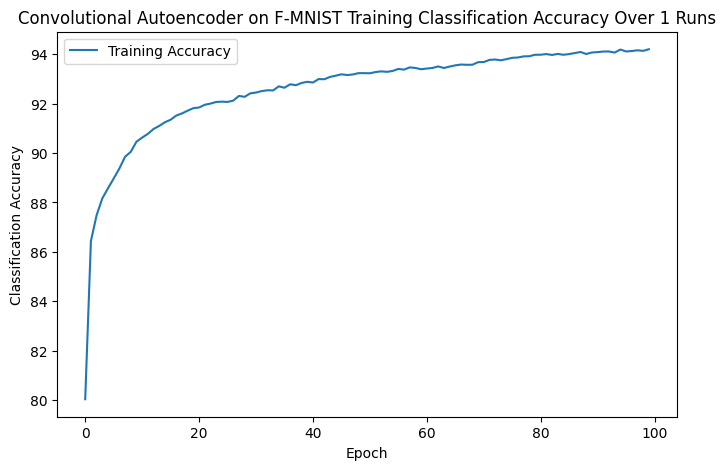

In [9]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on F-MNIST Training Classification Accuracy Over 1 Runs")
plt.show()

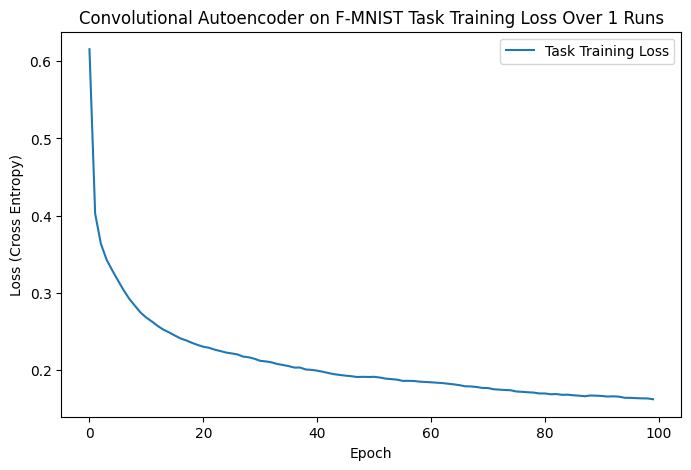

In [10]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Task Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on F-MNIST Task Training Loss Over 1 Runs")
plt.show()

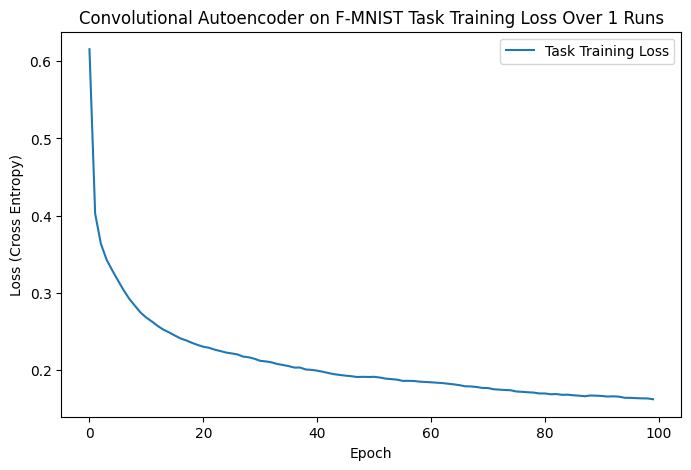

In [11]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Task Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("Convolutional Autoencoder on F-MNIST Task Training Loss Over 1 Runs")
plt.show()

# kernels

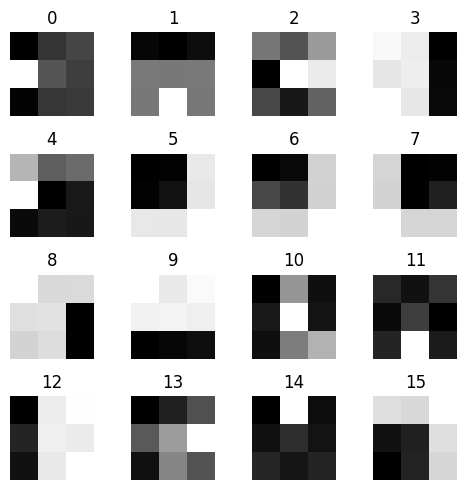

In [17]:
weights = feature_hist[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i,0], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

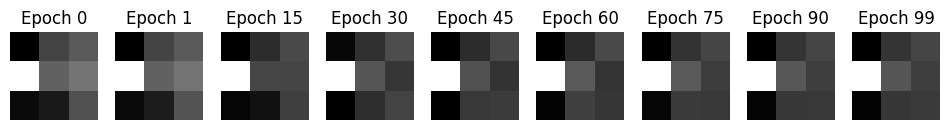

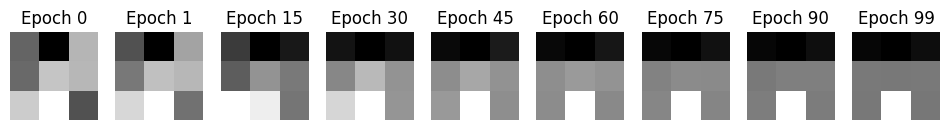

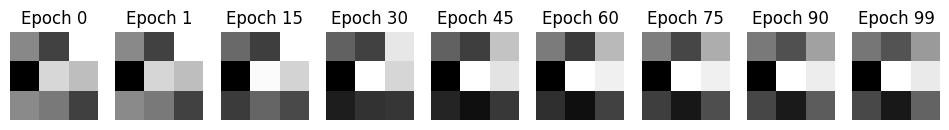

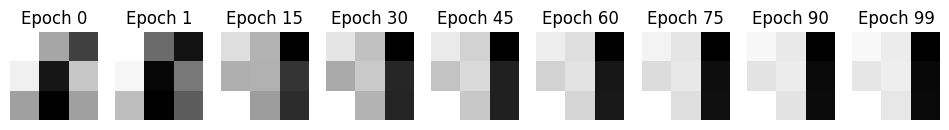

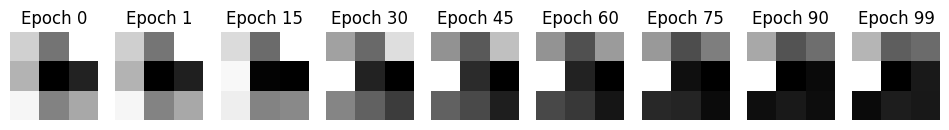

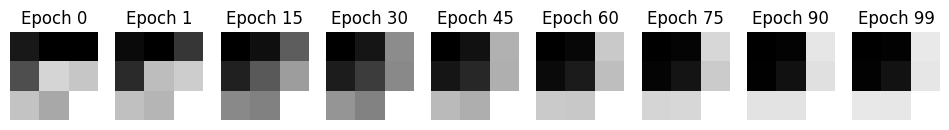

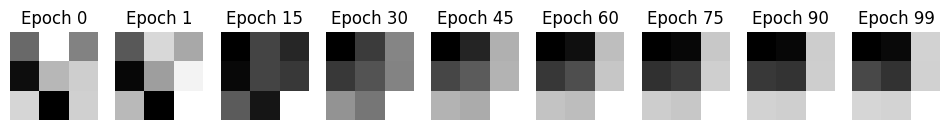

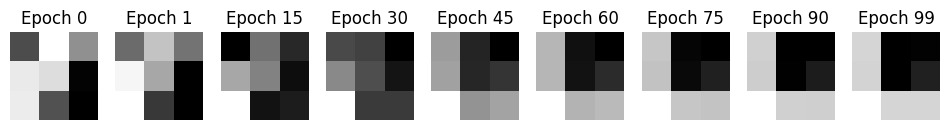

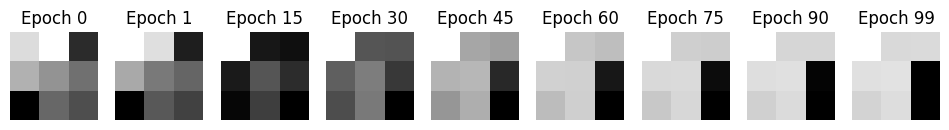

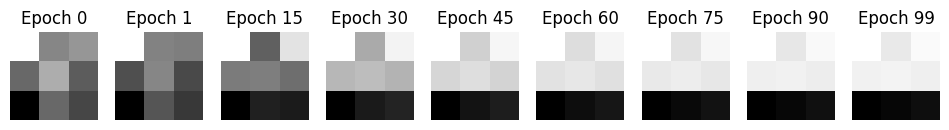

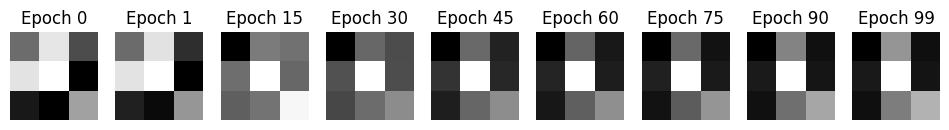

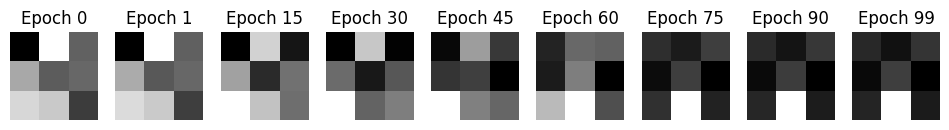

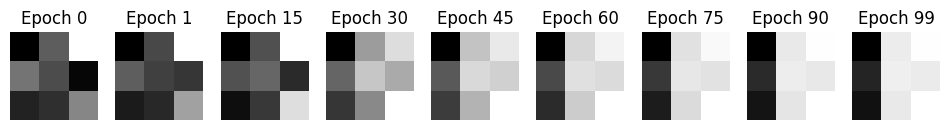

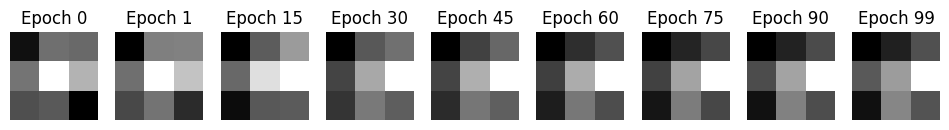

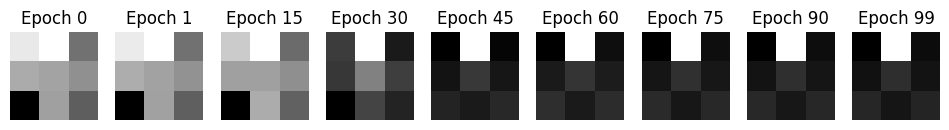

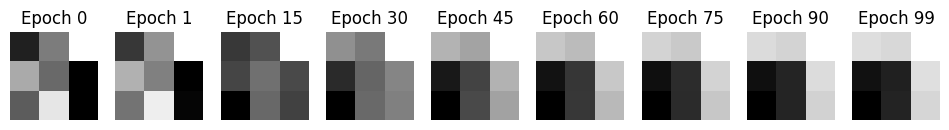

In [19]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_hist[epoch]["encoder_weights"][filter_idx,0]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [21]:
import torch.nn.functional as F 

encoder_weights = model.encoder.weight.flatten(1)

encoder_weights = F.normalize(encoder_weights, dim=1)

similarity_matrix = encoder_weights @ encoder_weights.T

mask = ~torch.eye(model.n_filters, dtype=torch.bool, device=encoder_weights.device)

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.3131
Mean filter cosine similarity: 0.1727
Maximum filter similarity: 0.9874
Minimum filter similarity: -0.6363


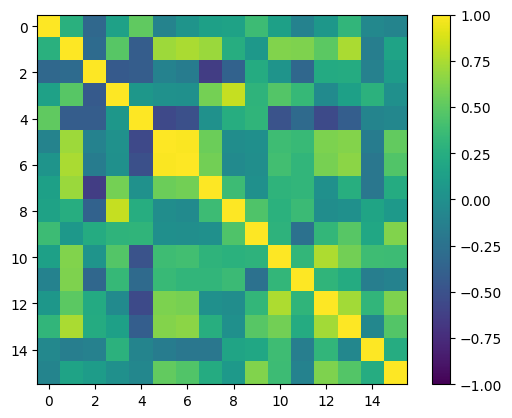

In [22]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

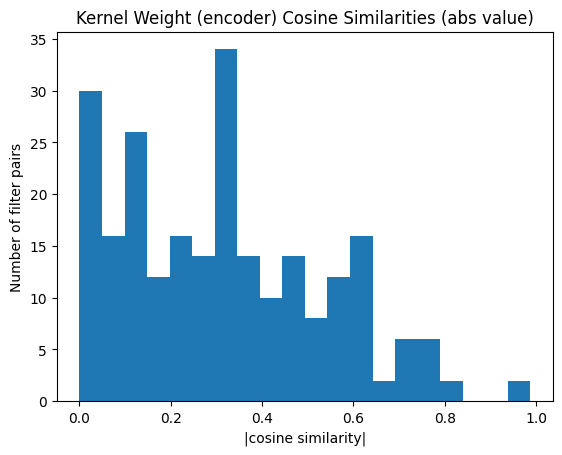

In [23]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight (encoder) Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Features

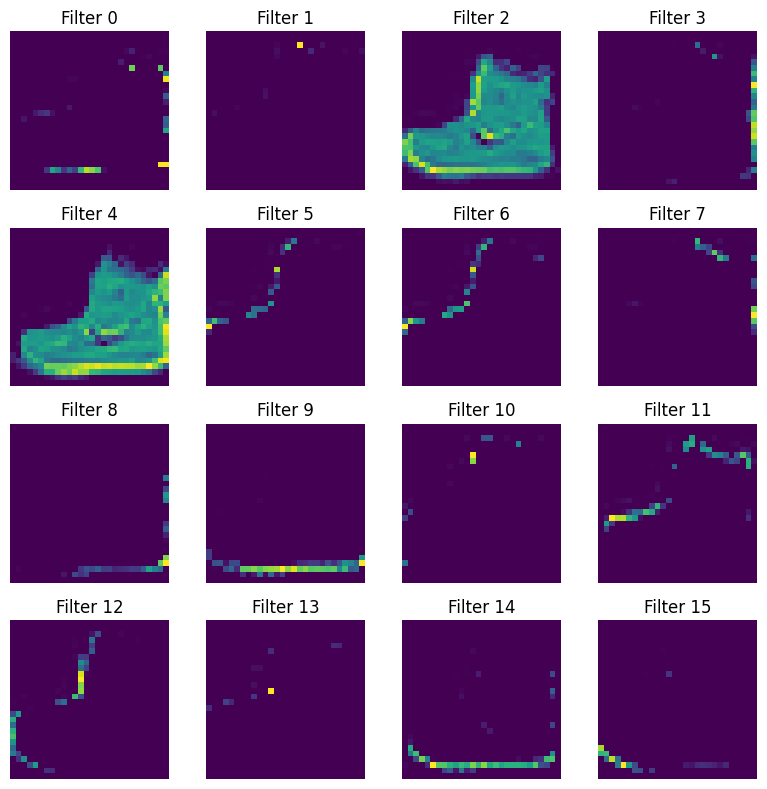

In [14]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_hist[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

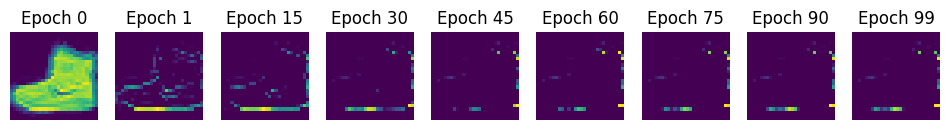

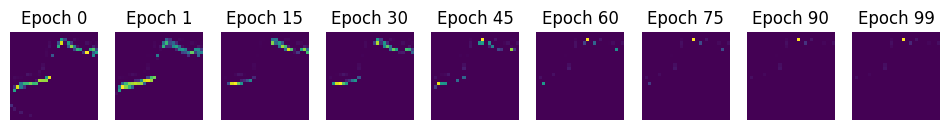

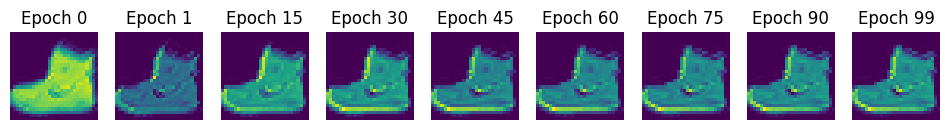

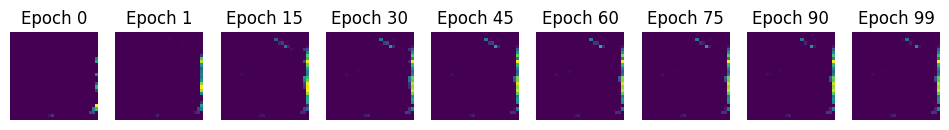

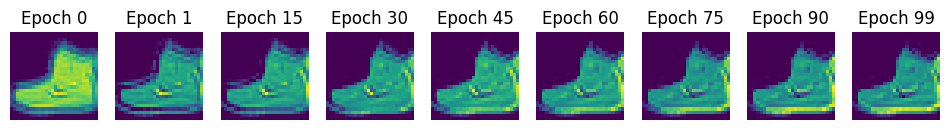

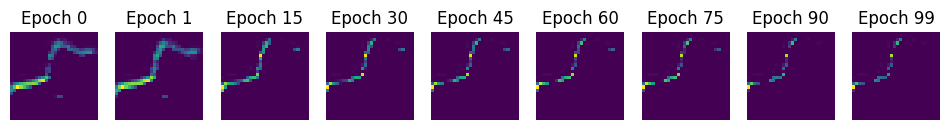

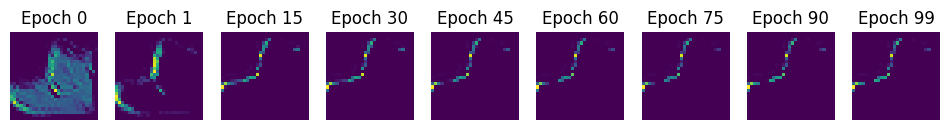

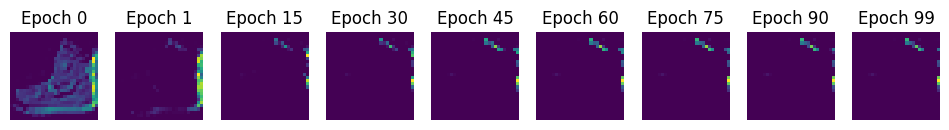

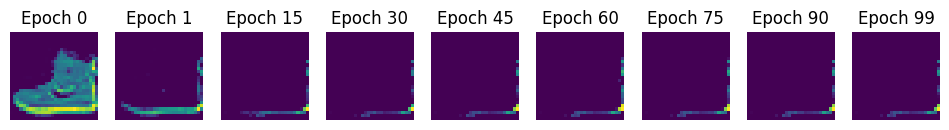

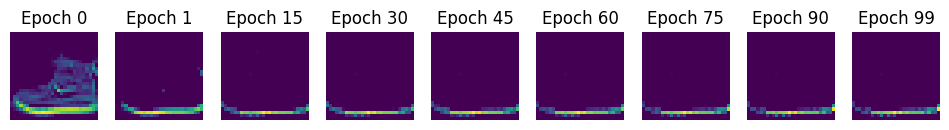

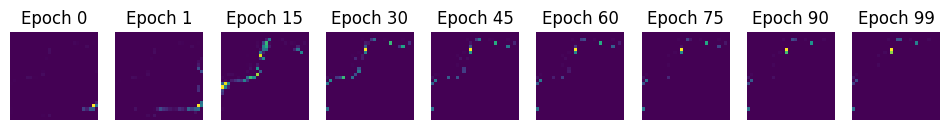

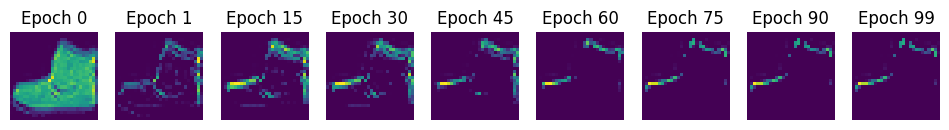

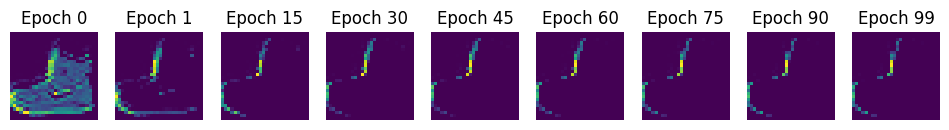

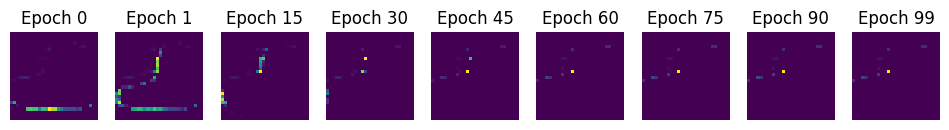

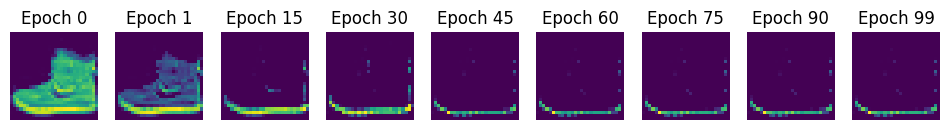

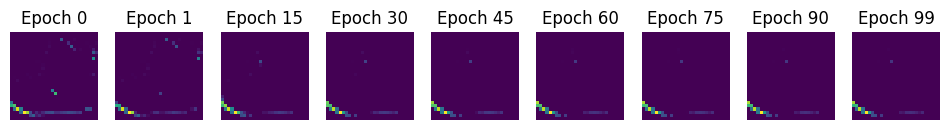

In [16]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i

    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))


    for ax, epoch in zip(axes, epochs):

        fmap = feature_hist[epoch]["maps"][0,filter_idx]

        ax.imshow(fmap,cmap="viridis")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [25]:
maps = feature_hist[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.1717)
tensor(0.9683)


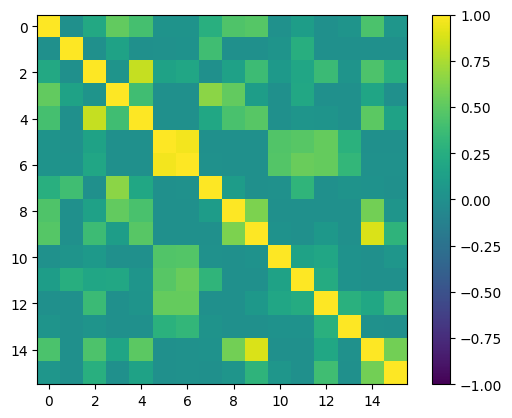

In [26]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

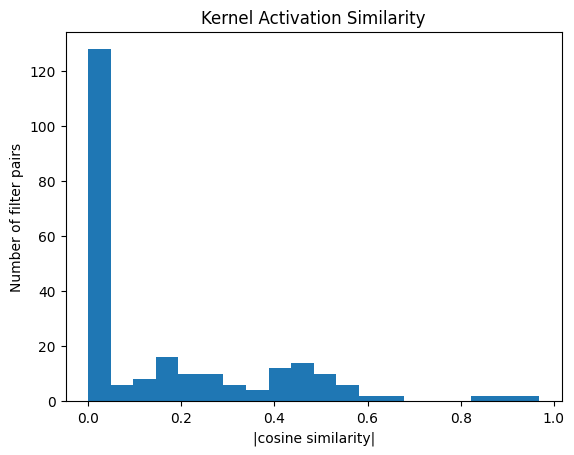

In [27]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Filters as Autoencoders

In [6]:
#get model
#from src.models import nan_cnn


#get experiment
from src.experiments import nan_cnn_experiment

In [39]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): # just 1 run

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = nan_cnn_experiment.train_nan_cnn_show_features(
        fmnist,
        input_dims=28,
        learning_rate=0.001,
        dual_lr=False,
        bias=True,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.1413
Epoch [1/100], Task Training Loss: 0.5714, Accuracy: 80.41%
Epoch [2/100], Encoder Training Loss: 0.0825
Epoch [2/100], Task Training Loss: 0.4129, Accuracy: 85.44%
Epoch [3/100], Encoder Training Loss: 0.0596
Epoch [3/100], Task Training Loss: 0.3978, Accuracy: 86.00%
Epoch [4/100], Encoder Training Loss: 0.0461
Epoch [4/100], Task Training Loss: 0.3899, Accuracy: 86.26%
Epoch [5/100], Encoder Training Loss: 0.0368
Epoch [5/100], Task Training Loss: 0.3788, Accuracy: 86.67%
Epoch [6/100], Encoder Training Loss: 0.0302
Epoch [6/100], Task Training Loss: 0.3757, Accuracy: 86.66%
Epoch [7/100], Encoder Training Loss: 0.0254
Epoch [7/100], Task Training Loss: 0.3712, Accuracy: 86.69%
Epoch [8/100], Encoder Training Loss: 0.0217
Epoch [8/100], Task Training Loss: 0.3607, Accuracy: 87.25%
Epoch [9/100], Encoder Training Loss: 0.0186
Epoch [9/100], Task Training Loss: 0.3574, Accuracy: 87.32%
Epoch [10/100], Encoder Tr

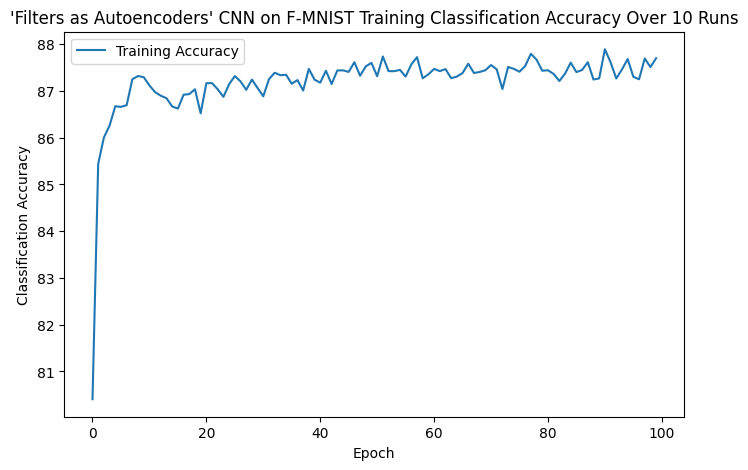

In [40]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

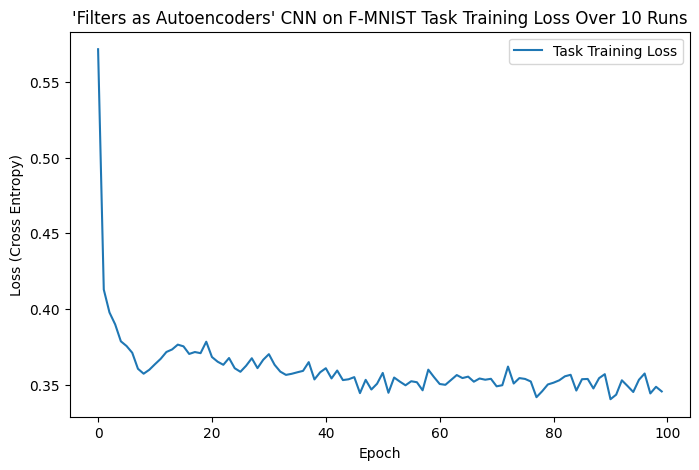

In [41]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Task Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Task Training Loss Over 10 Runs")
plt.show()

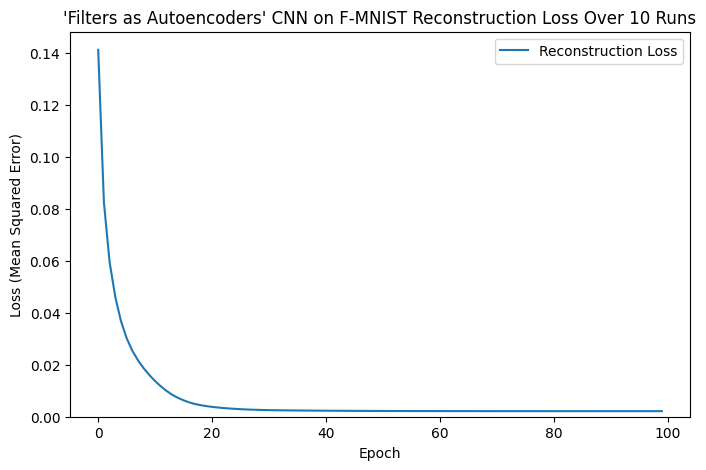

In [42]:
epochs = np.arange(len(training_history["encoder_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["encoder_train_loss"],label="Reconstruction Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom =0)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Reconstruction Loss Over 10 Runs")
plt.show()

# kernels learnt

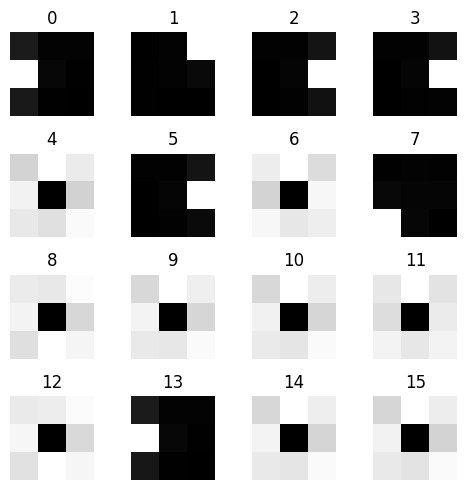

In [43]:
weights = feature_history[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()

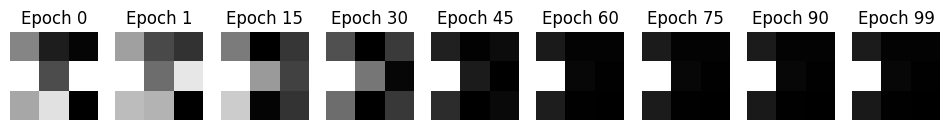

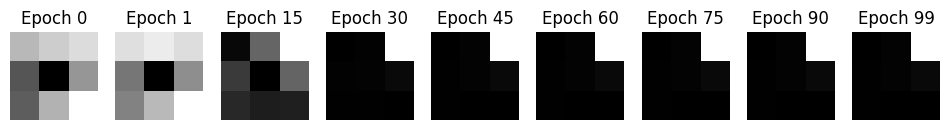

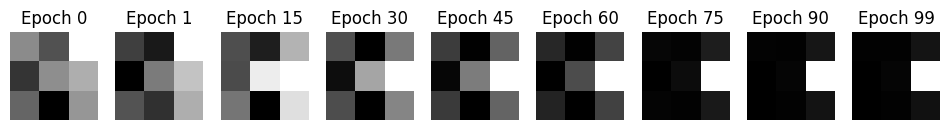

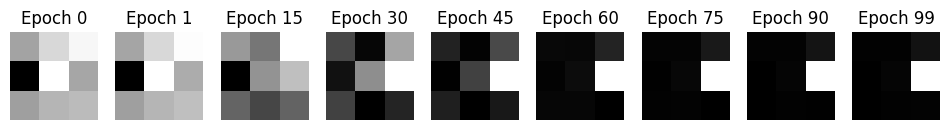

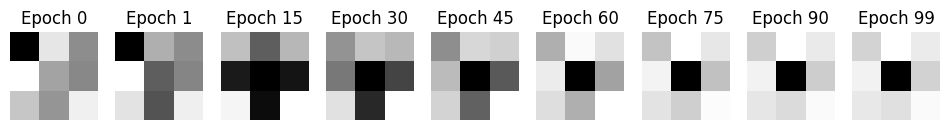

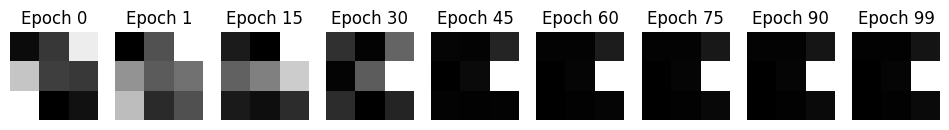

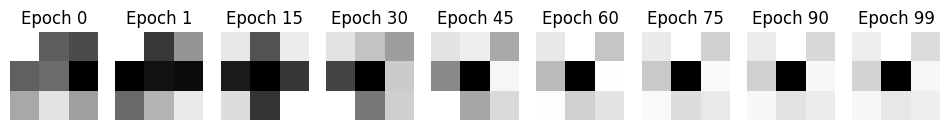

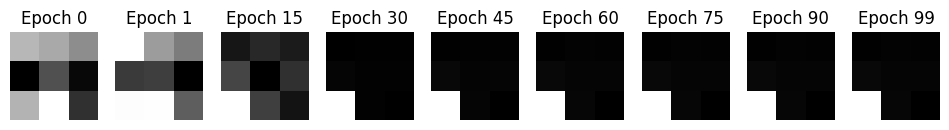

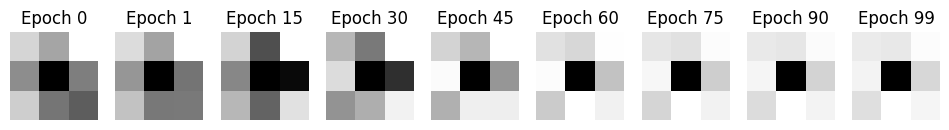

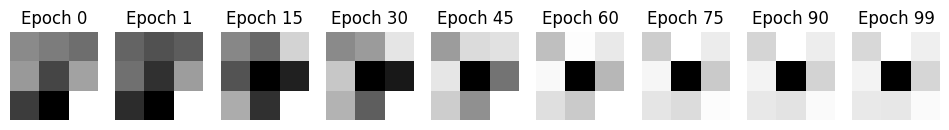

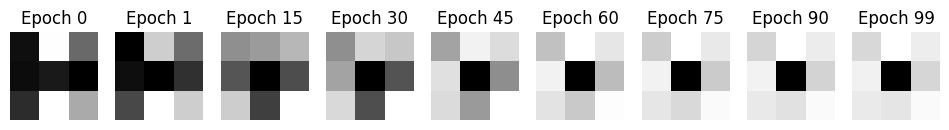

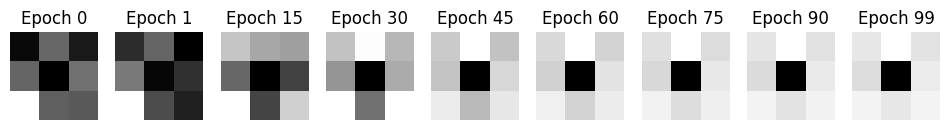

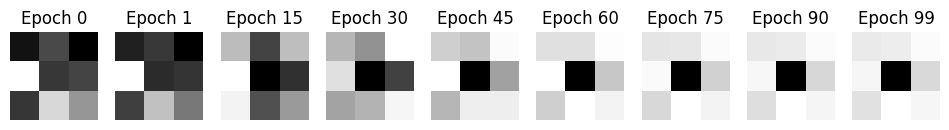

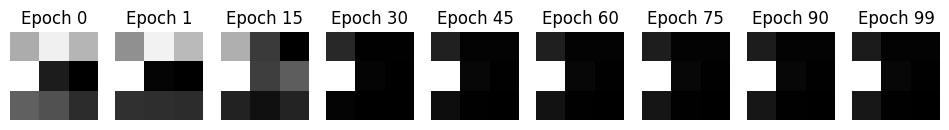

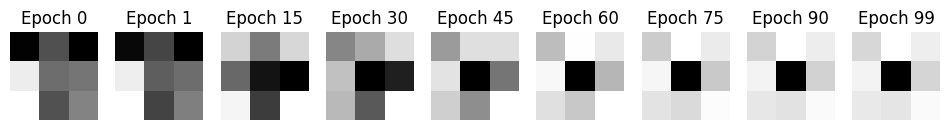

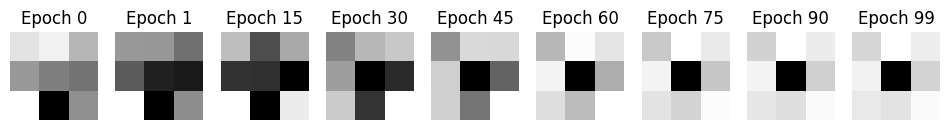

In [44]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_history[epoch]["encoder_weights"][filter_idx]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [45]:
import torch.nn.functional as F 
weights = torch.stack([
    F.normalize(f.encoder.weight.view(-1), dim=0)
    for f in model.filters
])

similarity_matrix = weights @ weights.T

mask = ~torch.eye(16, dtype=torch.bool, device="cuda")

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.3670
Mean filter cosine similarity: 0.3024
Maximum filter similarity: 1.0000
Minimum filter similarity: -0.1342


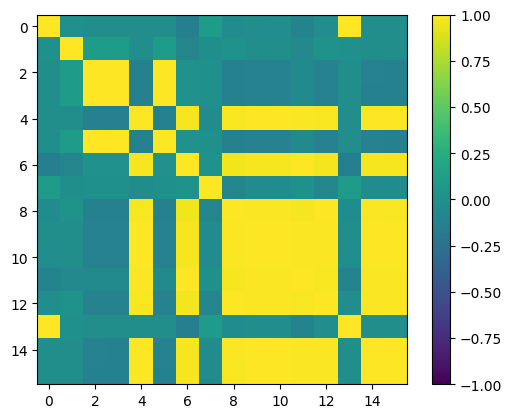

In [46]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

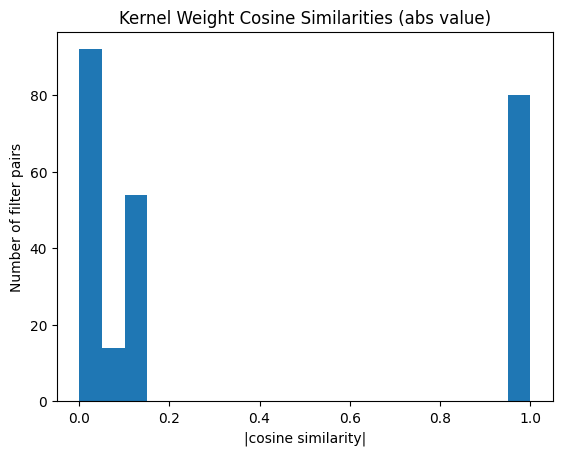

In [47]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Features

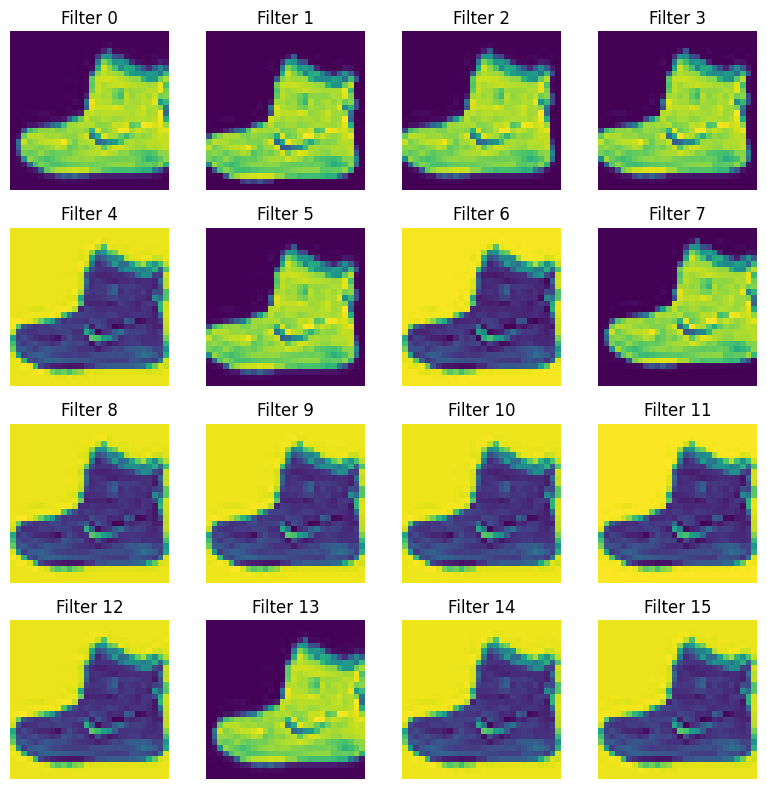

In [48]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

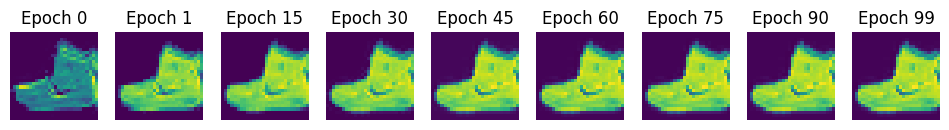

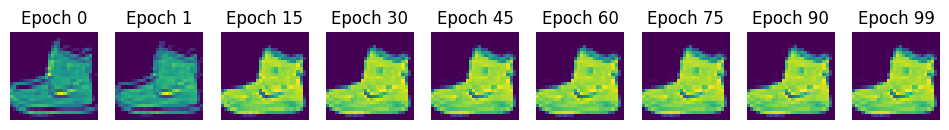

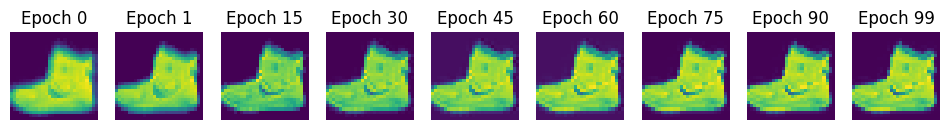

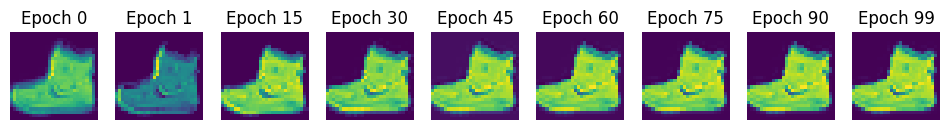

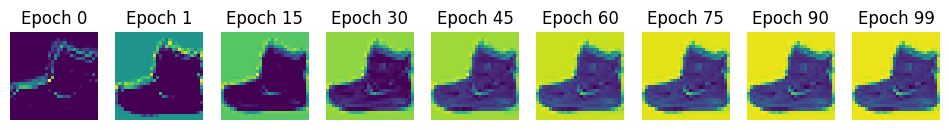

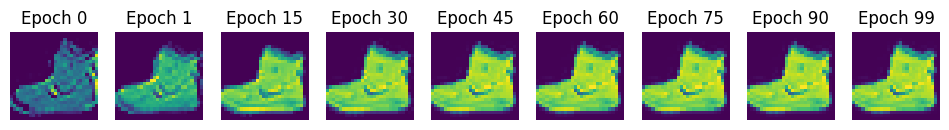

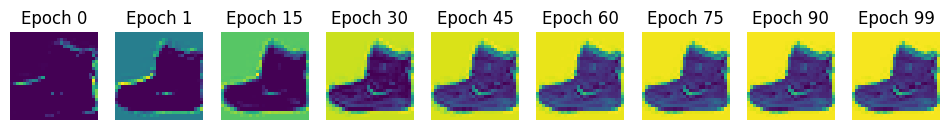

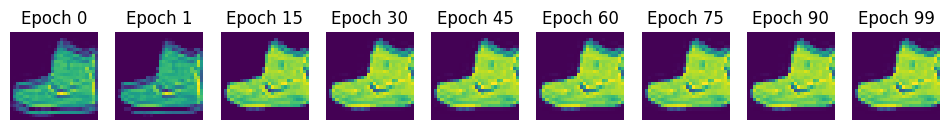

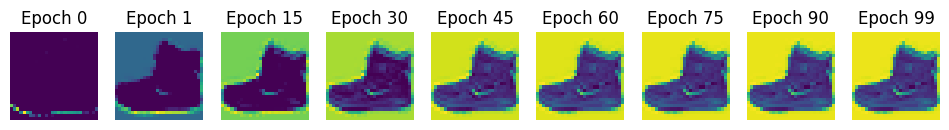

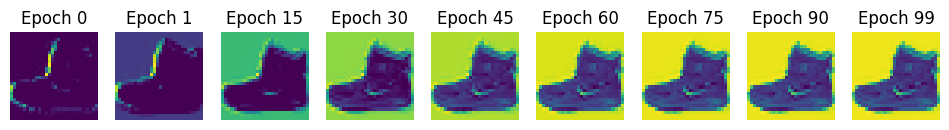

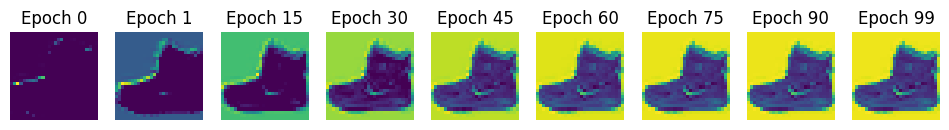

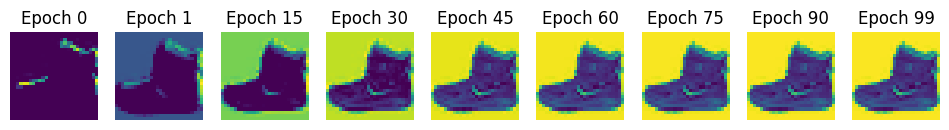

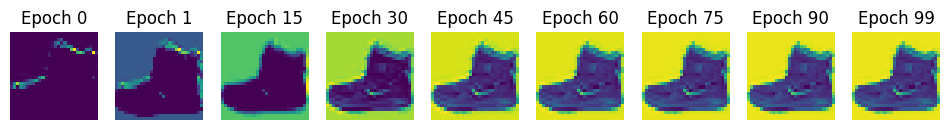

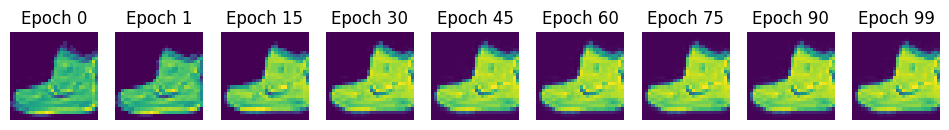

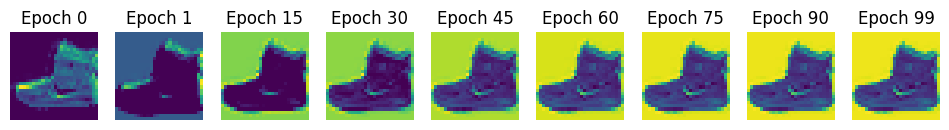

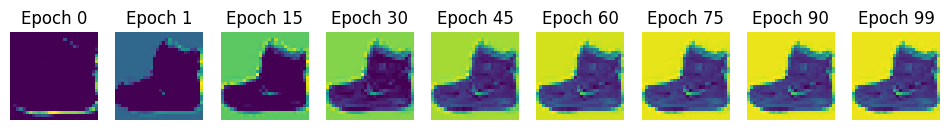

In [49]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [50]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.7139)
tensor(1.0000)


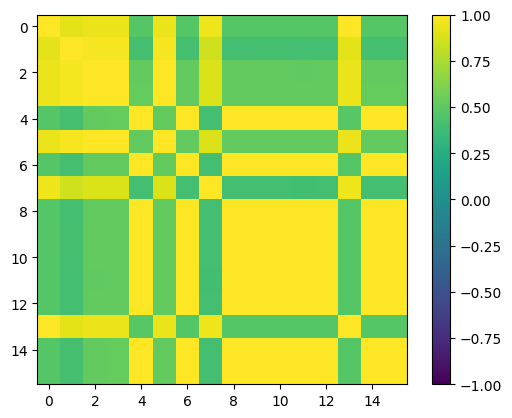

In [51]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

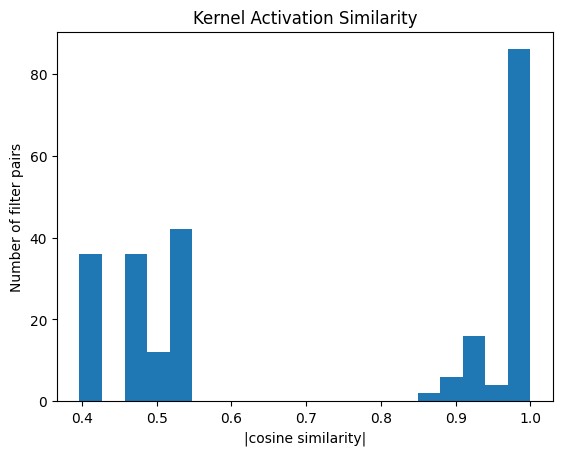

In [52]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Removing the bias and sharing the weights:

In [ ]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): # just 1 run

    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = nan_cnn_experiment.train_nan_cnn_weight_share_show_features(
        fmnist,
        input_dims=28,
        learning_rate=0.001,
        dual_lr=False,
        bias=False,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        pool_kernel_size=2,
        pool_stride=2,
        n_classes=10,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.1551
Epoch [1/100], Task Training Loss: 0.5522, Accuracy: 80.99%
Epoch [2/100], Encoder Training Loss: 0.1454
Epoch [2/100], Task Training Loss: 0.3778, Accuracy: 86.74%
Epoch [3/100], Encoder Training Loss: 0.1421
Epoch [3/100], Task Training Loss: 0.3619, Accuracy: 87.43%
Epoch [4/100], Encoder Training Loss: 0.1406
Epoch [4/100], Task Training Loss: 0.3541, Accuracy: 87.65%
Epoch [5/100], Encoder Training Loss: 0.1396
Epoch [5/100], Task Training Loss: 0.3425, Accuracy: 88.08%
Epoch [6/100], Encoder Training Loss: 0.1390
Epoch [6/100], Task Training Loss: 0.3351, Accuracy: 88.17%
Epoch [7/100], Encoder Training Loss: 0.1385
Epoch [7/100], Task Training Loss: 0.3343, Accuracy: 88.03%
Epoch [8/100], Encoder Training Loss: 0.1381
Epoch [8/100], Task Training Loss: 0.3254, Accuracy: 88.48%
Epoch [9/100], Encoder Training Loss: 0.1378
Epoch [9/100], Task Training Loss: 0.3177, Accuracy: 88.80%
Epoch [10/100], Encoder Tr

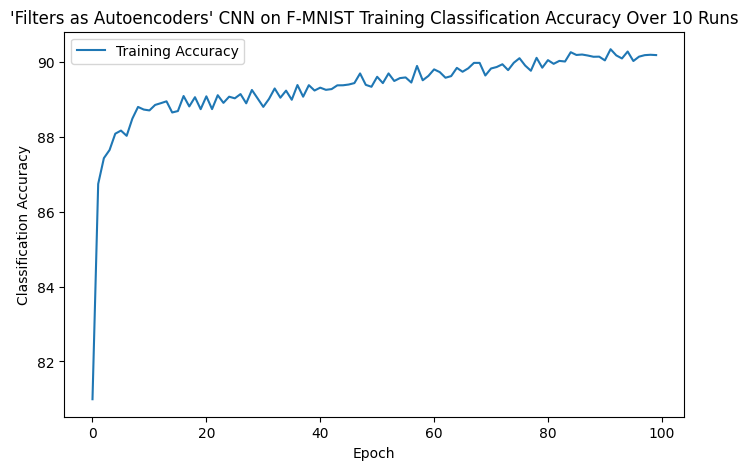

In [32]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

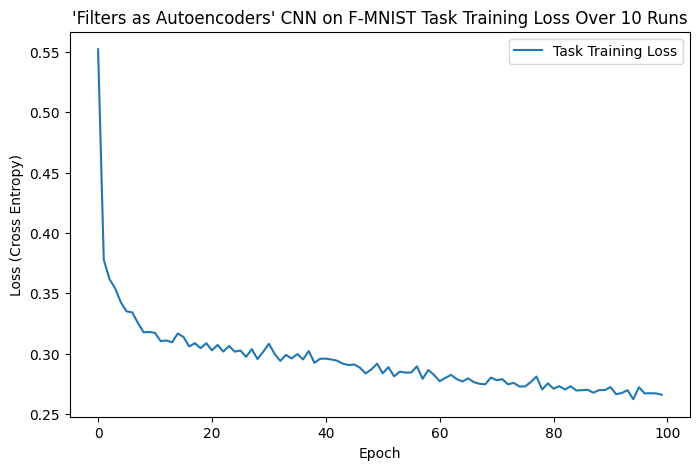

In [38]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Task Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Task Training Loss Over 10 Runs")
plt.show()

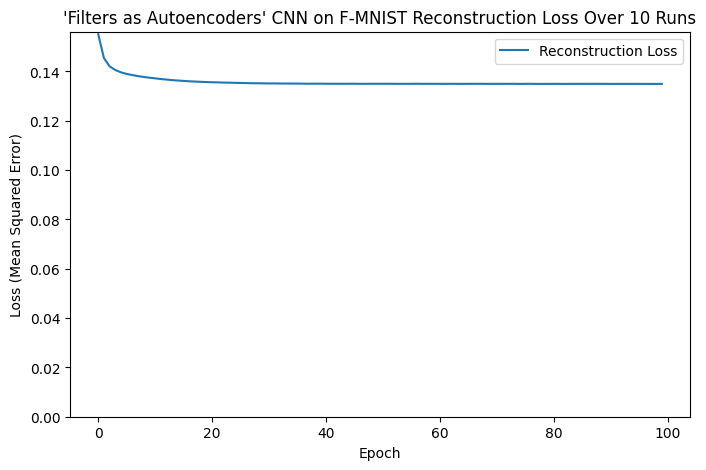

In [37]:
epochs = np.arange(len(training_history["encoder_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["encoder_train_loss"],label="Reconstruction Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom =0)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Reconstruction Loss Over 10 Runs")
plt.show()

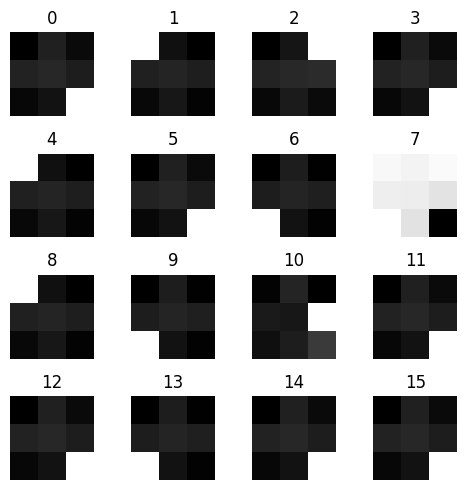

In [15]:
weights = feature_history[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()


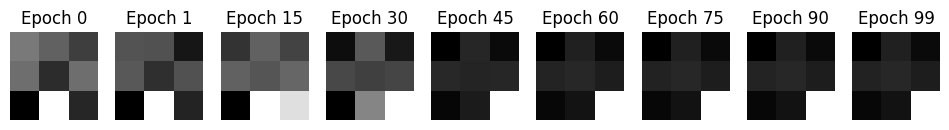

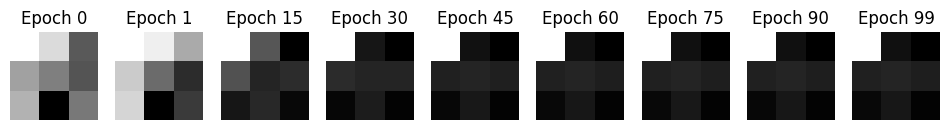

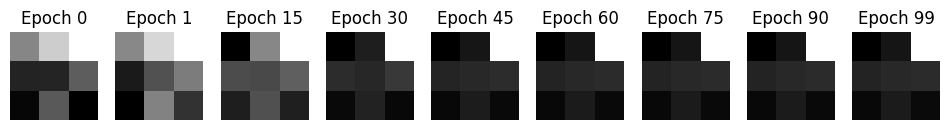

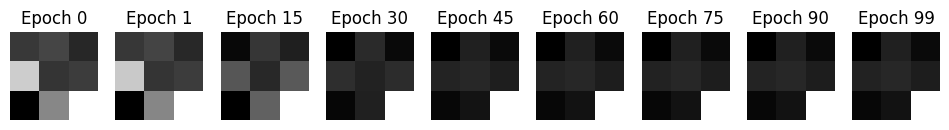

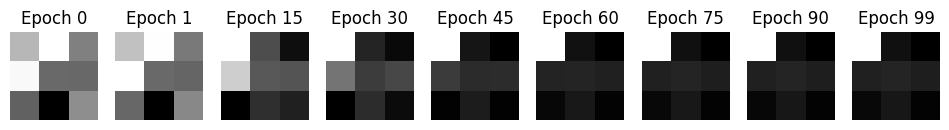

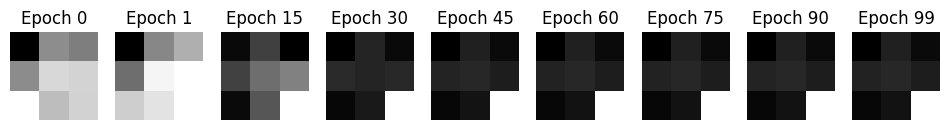

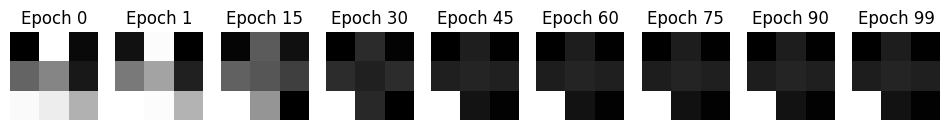

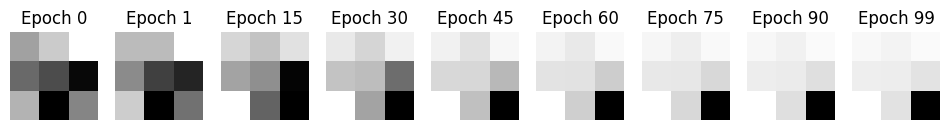

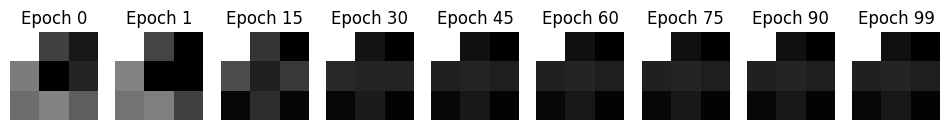

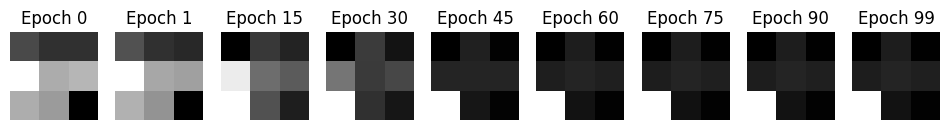

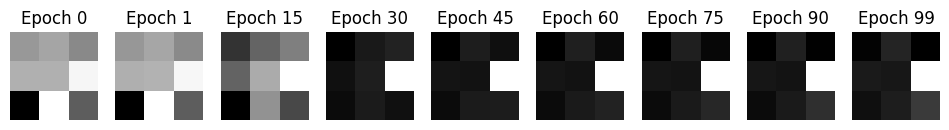

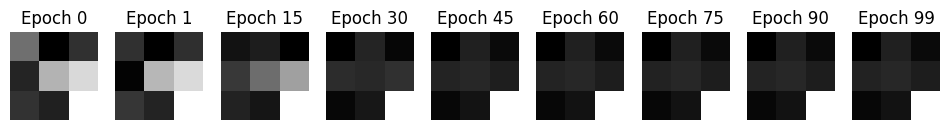

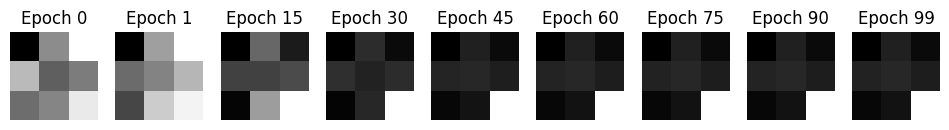

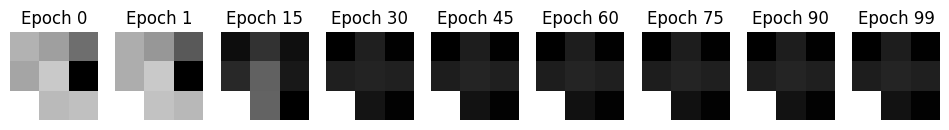

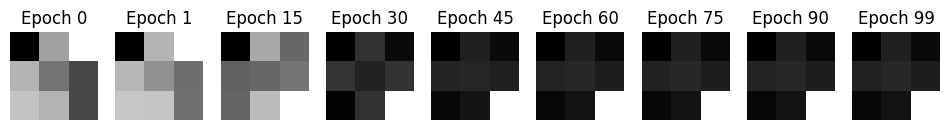

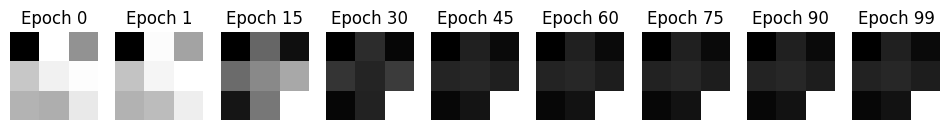

In [16]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_history[epoch]["encoder_weights"][filter_idx]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [17]:
import torch.nn.functional as F 
weights = torch.stack([
    F.normalize(f.encoder.weight.view(-1), dim=0)
    for f in model.filters
])

similarity_matrix = weights @ weights.T

mask = ~torch.eye(16, dtype=torch.bool, device="cuda")

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")


Mean abs filter cosine similarity: 0.4310
Mean filter cosine similarity: 0.0528
Maximum filter similarity: 1.0000
Minimum filter similarity: -0.9658


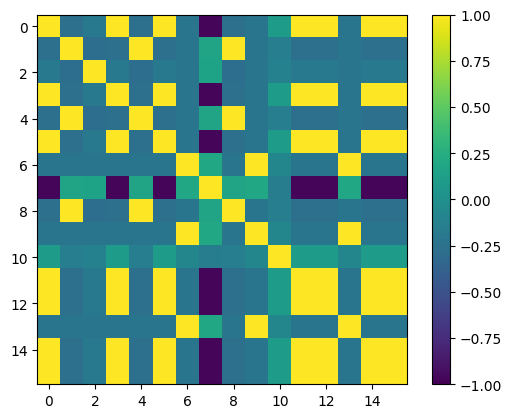

In [18]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

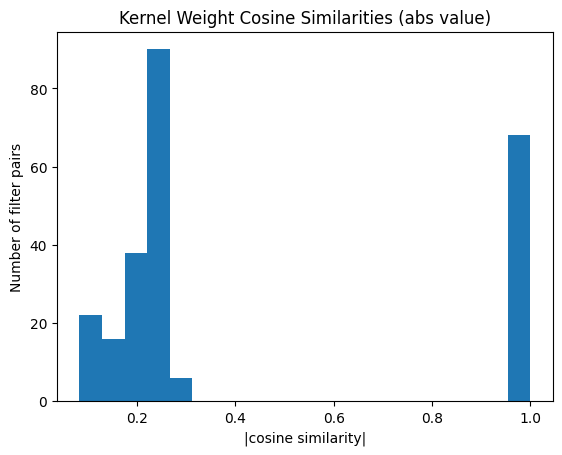

In [19]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

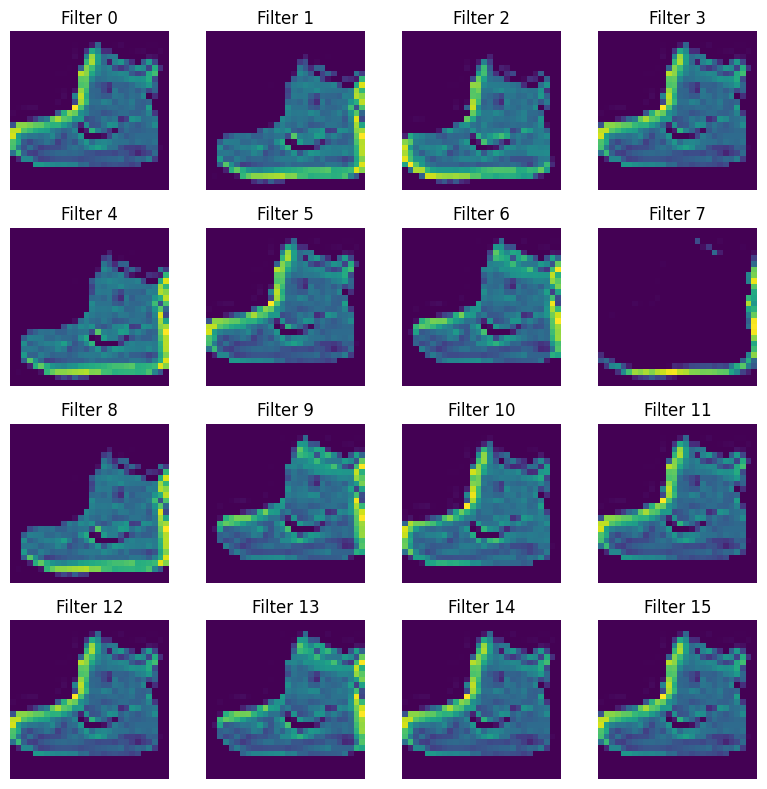

In [20]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

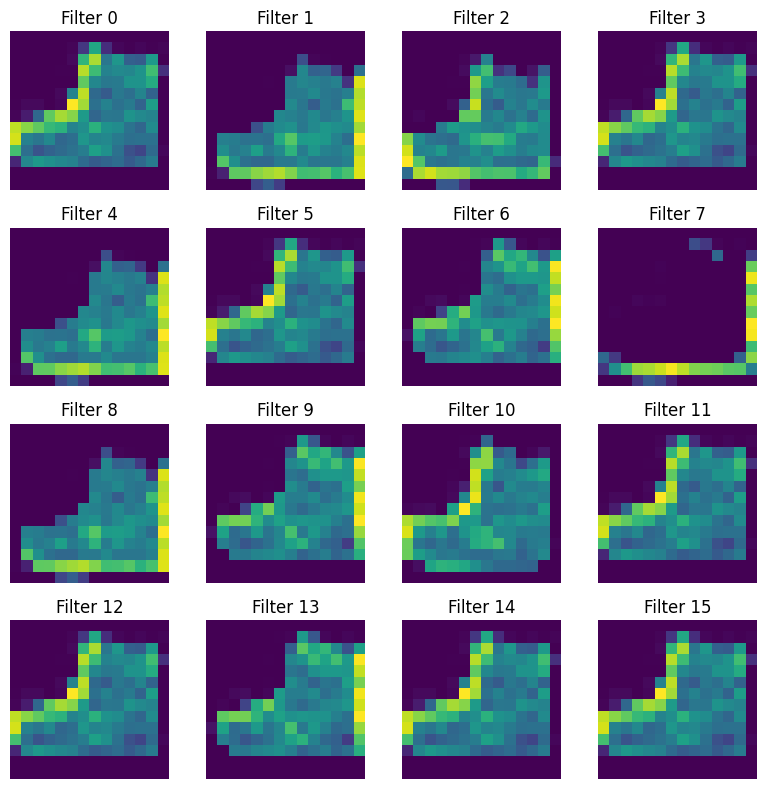

In [21]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["pooled_maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

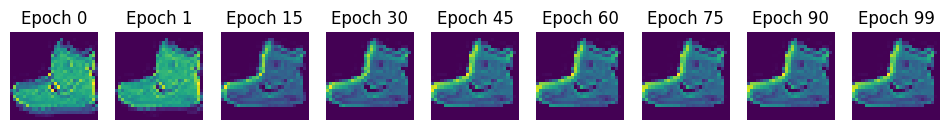

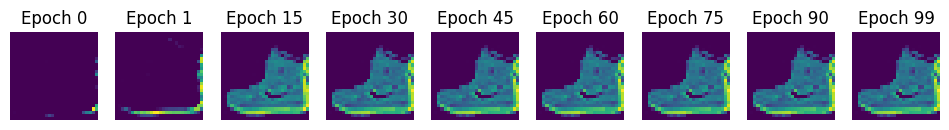

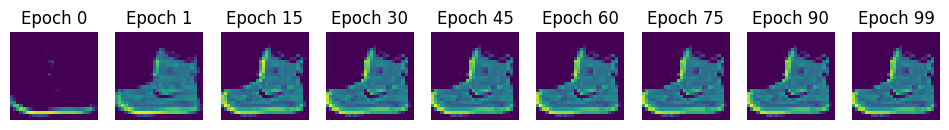

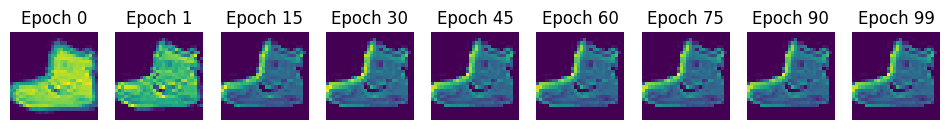

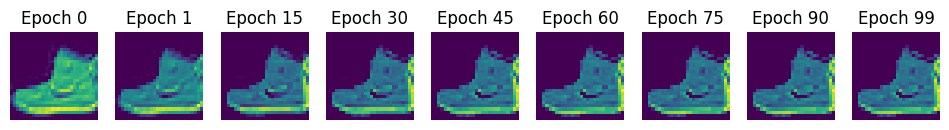

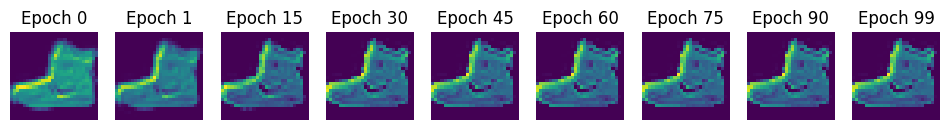

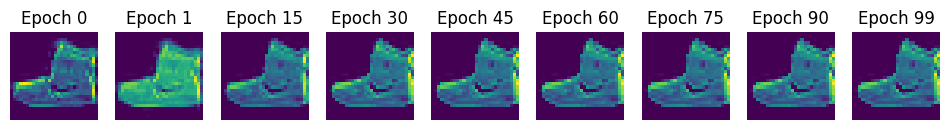

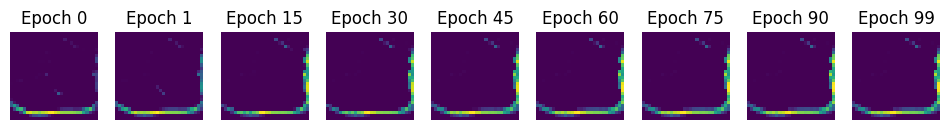

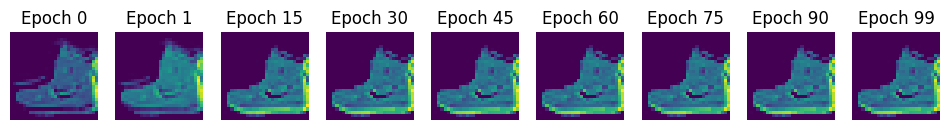

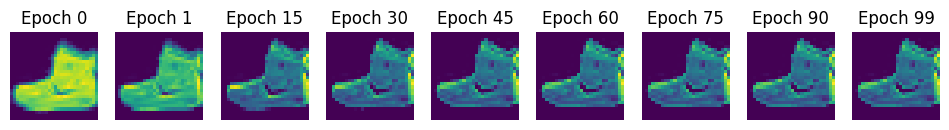

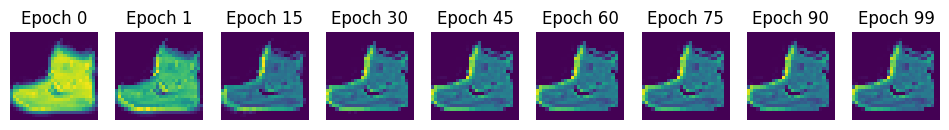

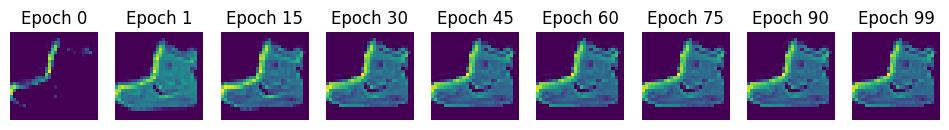

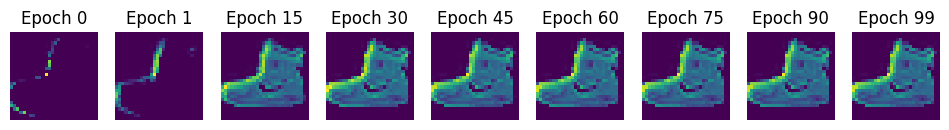

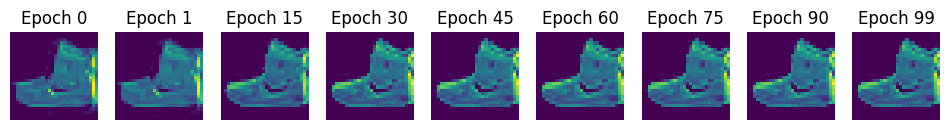

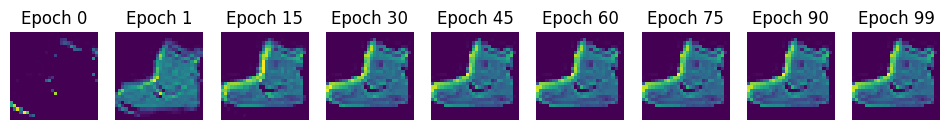

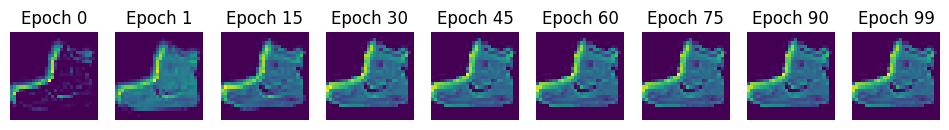

In [22]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [23]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.6893)
tensor(1.0000)


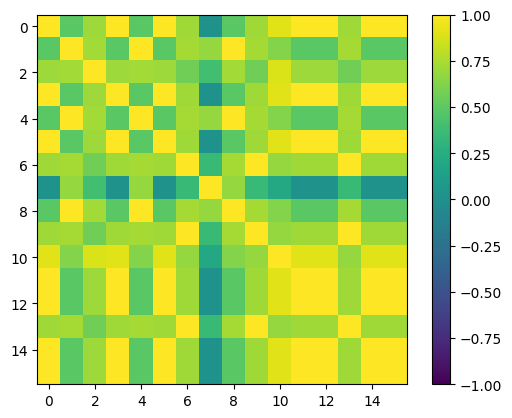

In [24]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

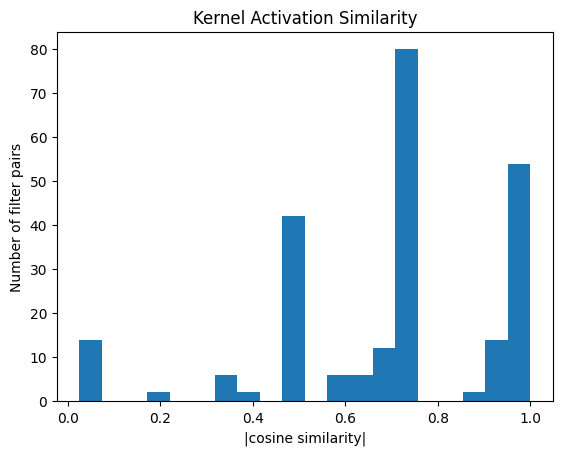

In [25]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Use separate learning rates with bias and separate autoencoder weights

In [17]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): #10 runs with 1 warm up
    #run training and evaluation


    print(f"model run: {seed}")


    model, training_history, elapsed = nan_cnn_experiment.train_nan_cnn(
        fmnist,
        input_dims=28,
        in_channels=1,
        dual_lr= True,
        classifier_lr=0.001,
        #ae_lr=0.00001,
        ae_lr=0.000001, 
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        n_classes=10,
        bias=True,
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.1775
Epoch [1/100], Task Training Loss: 0.5832, Accuracy: 80.33%
Epoch [2/100], Encoder Training Loss: 0.1774
Epoch [2/100], Task Training Loss: 0.3961, Accuracy: 86.44%
Epoch [3/100], Encoder Training Loss: 0.1773
Epoch [3/100], Task Training Loss: 0.3584, Accuracy: 87.73%
Epoch [4/100], Encoder Training Loss: 0.1772
Epoch [4/100], Task Training Loss: 0.3382, Accuracy: 88.25%
Epoch [5/100], Encoder Training Loss: 0.1772
Epoch [5/100], Task Training Loss: 0.3232, Accuracy: 88.86%
Epoch [6/100], Encoder Training Loss: 0.1771
Epoch [6/100], Task Training Loss: 0.3119, Accuracy: 89.05%
Epoch [7/100], Encoder Training Loss: 0.1770
Epoch [7/100], Task Training Loss: 0.3031, Accuracy: 89.31%
Epoch [8/100], Encoder Training Loss: 0.1770
Epoch [8/100], Task Training Loss: 0.2950, Accuracy: 89.57%
Epoch [9/100], Encoder Training Loss: 0.1769
Epoch [9/100], Task Training Loss: 0.2874, Accuracy: 89.82%
Epoch [10/100], Encoder Tr

average over final 10 epochs for seed =0

In [19]:
94.44 + 94.34 + 94.41+ 94.32 + 94.27 + 94.25+ 94.17+94.19+94.14+94.19

942.7199999999998

# Using separate learning rates for weight tied and bias ommiting:

In [81]:
all_encoder_histories = []
all_task_histories = []
all_accuracy_histories=[]
peak_memory =[]
run_times= []

for seed in range(1): #10 runs with 1 warm up
    #run training and evaluation


    print(f"model run: {seed}")


    model, training_history,feature_history, elapsed = nan_cnn_experiment.train_nan_cnn_weight_share_show_features(
        fmnist,
        input_dims=28,
        in_channels=1,
        dual_lr= True,
        classifier_lr=0.001,
        #ae_lr=0.00001,
        ae_lr=0.000001, 
        learning_rate=0.001,
        n_epochs=100,      
        batch_size=256,
        n_filters=16,
        stride=1,
        padding=1,
        kernel_size=3,
        epochs_to_show=[0,1,15,30,45,60,75,90,99],
        n_classes=10,
        bias=False,
        seed=seed 
    )

    all_encoder_histories.append(training_history["encoder_train_loss"])
    all_task_histories.append(training_history["task_train_loss"])
    all_accuracy_histories.append(training_history["train_accuracy"])
    peak = torch.cuda.max_memory_allocated()

    peak_MB = peak / 1024**2
    print(f"peak memory from train : {peak_MB}")
    peak_memory.append(peak_MB)
    torch.cuda.reset_peak_memory_stats()
    print(f"memory now reset and is: {torch.cuda.max_memory_allocated()/ 1024**2} MB")
    print(f"time elapsed: {elapsed}")
    
    run_times.append(elapsed)

model run: 0
device is: cuda
Epoch [1/100], Encoder Training Loss: 0.1682
Epoch [1/100], Task Training Loss: 0.5673, Accuracy: 80.64%
Epoch [2/100], Encoder Training Loss: 0.1681
Epoch [2/100], Task Training Loss: 0.3900, Accuracy: 86.69%
Epoch [3/100], Encoder Training Loss: 0.1681
Epoch [3/100], Task Training Loss: 0.3554, Accuracy: 87.79%
Epoch [4/100], Encoder Training Loss: 0.1680
Epoch [4/100], Task Training Loss: 0.3361, Accuracy: 88.45%
Epoch [5/100], Encoder Training Loss: 0.1680
Epoch [5/100], Task Training Loss: 0.3207, Accuracy: 88.92%
Epoch [6/100], Encoder Training Loss: 0.1679
Epoch [6/100], Task Training Loss: 0.3109, Accuracy: 89.18%
Epoch [7/100], Encoder Training Loss: 0.1679
Epoch [7/100], Task Training Loss: 0.3022, Accuracy: 89.37%
Epoch [8/100], Encoder Training Loss: 0.1679
Epoch [8/100], Task Training Loss: 0.2943, Accuracy: 89.67%
Epoch [9/100], Encoder Training Loss: 0.1678
Epoch [9/100], Task Training Loss: 0.2864, Accuracy: 89.92%
Epoch [10/100], Encoder Tr

average over final 10 epochs:

In [18]:
94.07+93.98+94.06+93.96+93.96+93.90+93.86+93.80+93.84+93.89

939.3199999999999

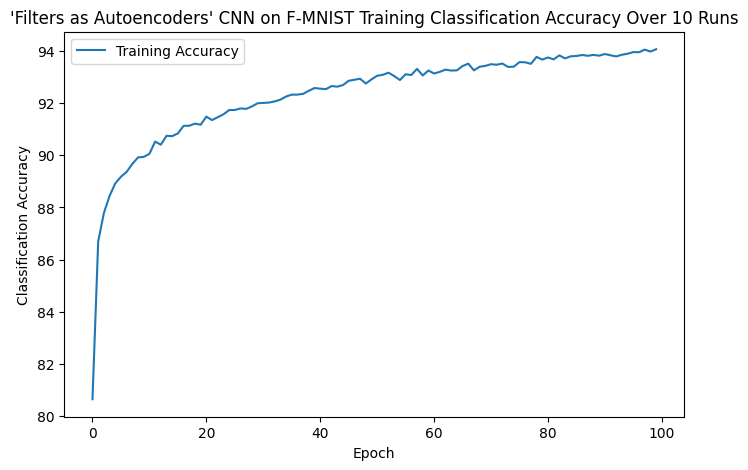

In [82]:
epochs = np.arange(len(training_history["train_accuracy"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["train_accuracy"],label="Training Accuracy")


plt.xlabel("Epoch")
plt.ylabel("Classification Accuracy")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Training Classification Accuracy Over 10 Runs")
plt.show()

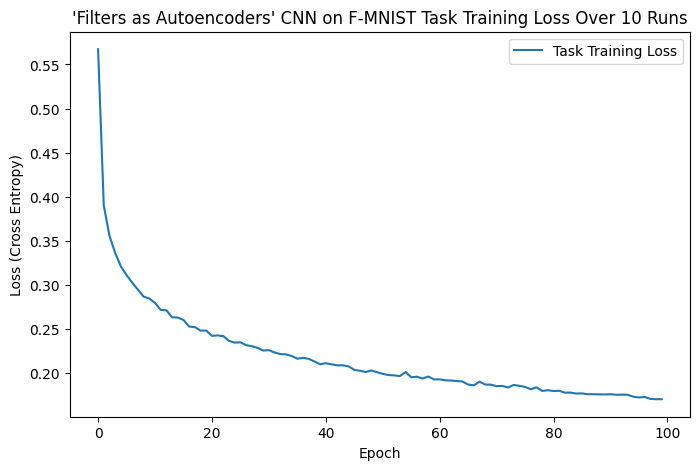

In [83]:
epochs = np.arange(len(training_history["task_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["task_train_loss"],label="Task Training Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Cross Entropy)")
plt.legend()
#plt.ylim(0,0.02)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Task Training Loss Over 10 Runs")
plt.show()

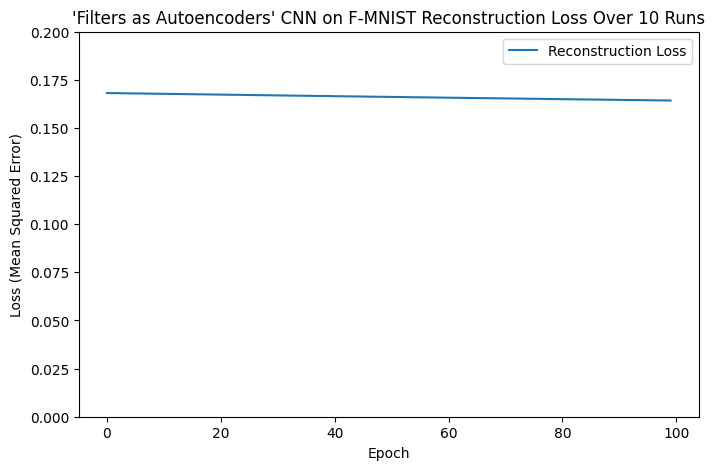

In [84]:
epochs = np.arange(len(training_history["encoder_train_loss"]))

plt.figure(figsize=(8,5))

plt.plot(epochs, training_history["encoder_train_loss"],label="Reconstruction Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss (Mean Squared Error)")
plt.legend()
plt.ylim(bottom =0, top =0.2)
plt.title("'Filters as Autoencoders' CNN on F-MNIST Reconstruction Loss Over 10 Runs")
plt.show()

# kernels learnt

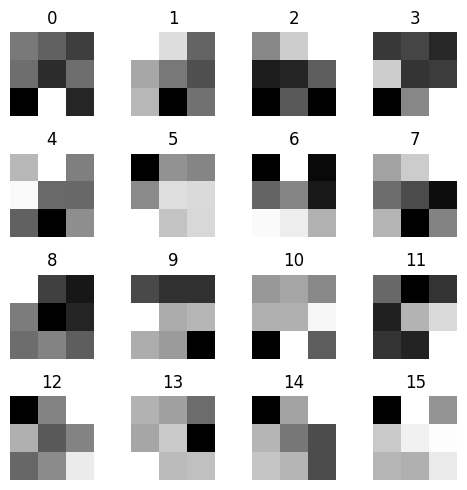

In [86]:
weights = feature_history[99]["encoder_weights"]

fig, axes = plt.subplots(4,4,figsize=(5,5))

for i, ax in enumerate(axes.flat):

    ax.imshow(weights[i], cmap="gray")
    ax.set_title(i)
    ax.axis("off")

plt.tight_layout()
plt.show()


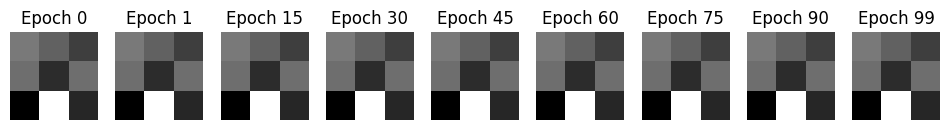

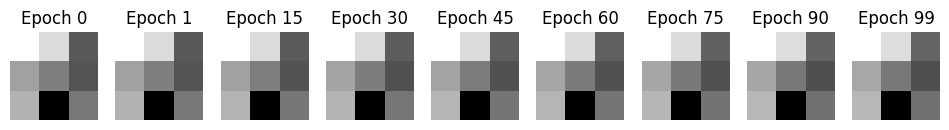

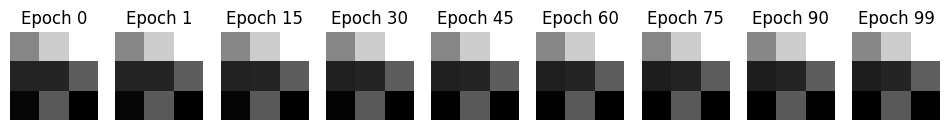

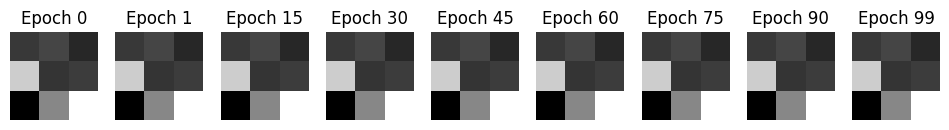

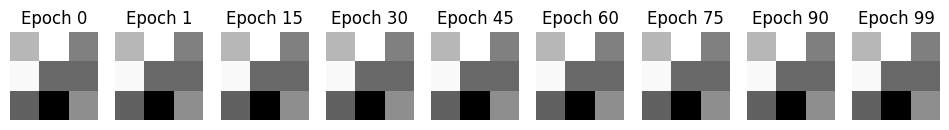

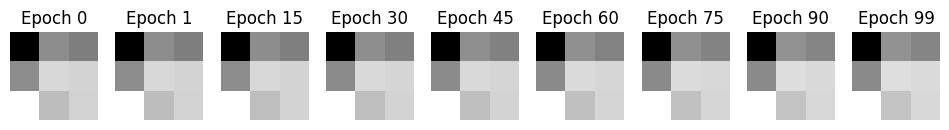

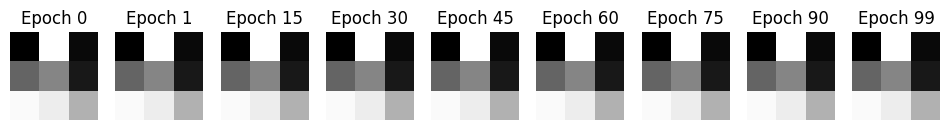

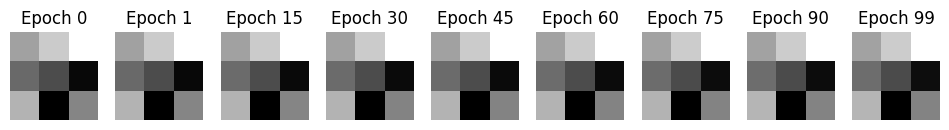

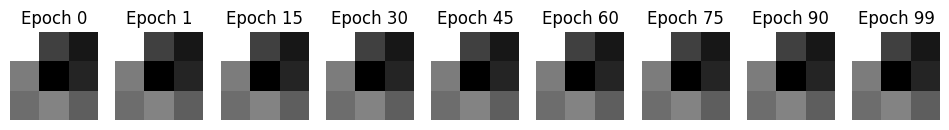

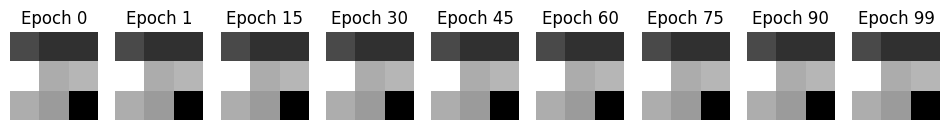

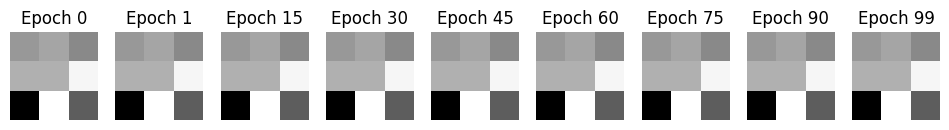

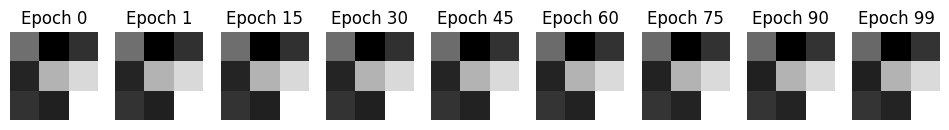

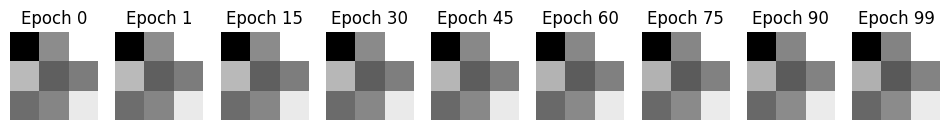

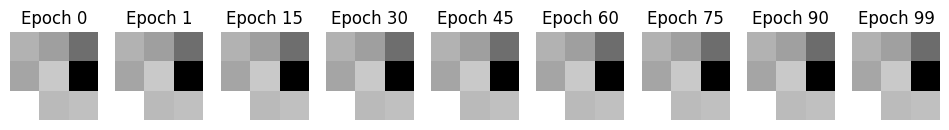

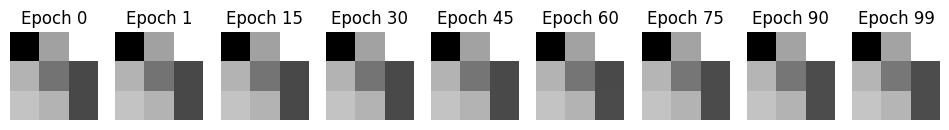

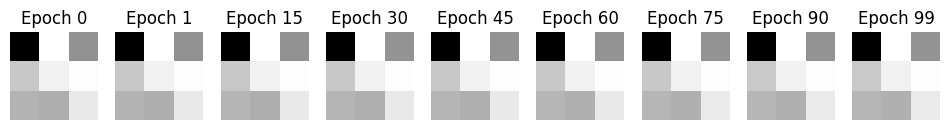

In [87]:
epochs = [0,1,15,30,45,60,75,90,99]
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        kernel = feature_history[epoch]["encoder_weights"][filter_idx]

        ax.imshow(kernel,cmap="gray")
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [88]:
import torch.nn.functional as F 
weights = torch.stack([
    F.normalize(f.encoder.weight.view(-1), dim=0)
    for f in model.filters
])

similarity_matrix = weights @ weights.T

mask = ~torch.eye(16, dtype=torch.bool, device="cuda")

mean_abs_similarity = similarity_matrix[mask].abs().mean()
mean_similarity = similarity_matrix[mask].mean()

max_similarity = similarity_matrix[mask].max()
min_similarity = similarity_matrix[mask].min()


print(f"Mean abs filter cosine similarity: {mean_abs_similarity:.4f}")
print(f"Mean filter cosine similarity: {mean_similarity:.4f}")

print(f"Maximum filter similarity: {max_similarity:.4f}")
print(f"Minimum filter similarity: {min_similarity:.4f}")

Mean abs filter cosine similarity: 0.2764
Mean filter cosine similarity: -0.0250
Maximum filter similarity: 0.7664
Minimum filter similarity: -0.7684


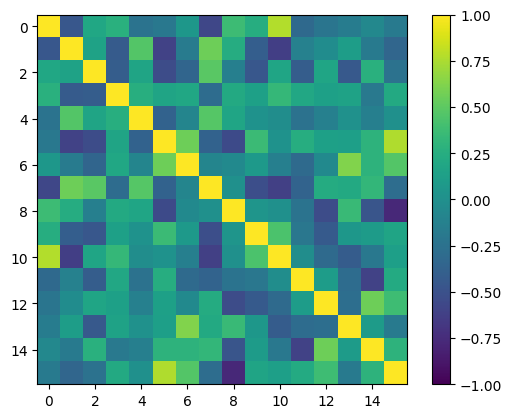

In [89]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

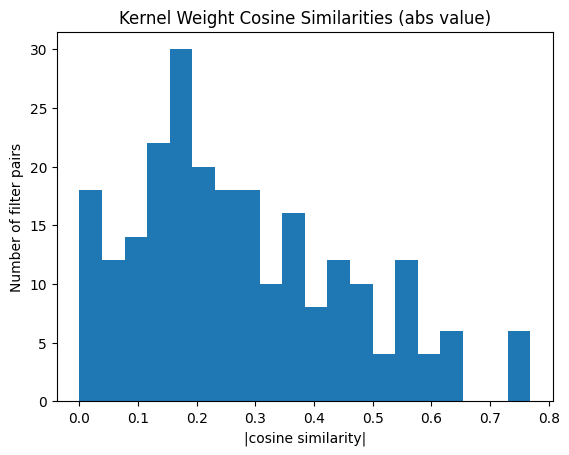

In [90]:
pairwise = similarity_matrix[mask].abs().detach().cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Weight Cosine Similarities (abs value)")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")

# Features

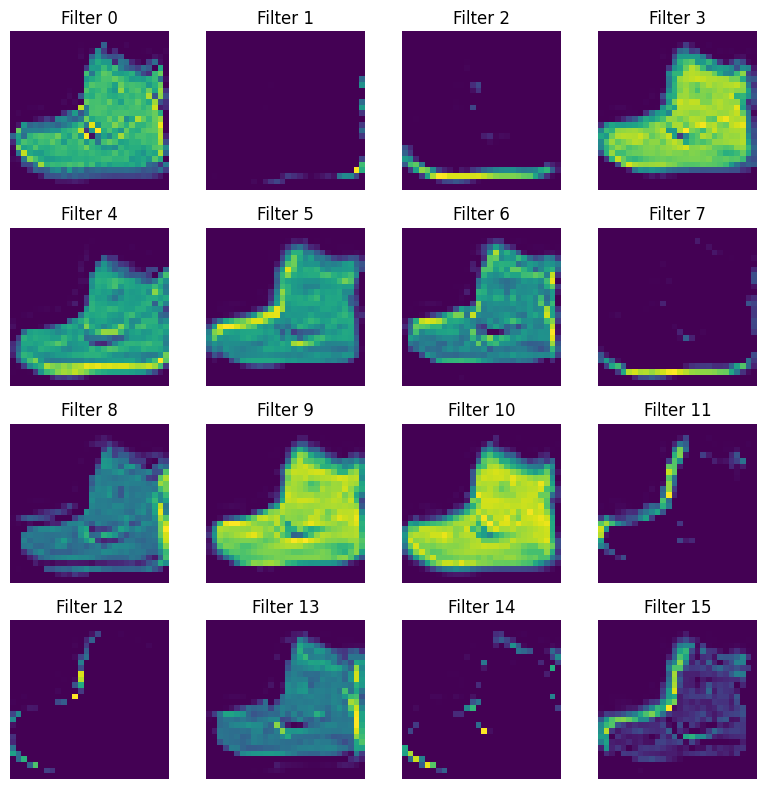

In [91]:
fig, axes = plt.subplots(4,4,figsize=(8,8))

maps = feature_history[99]["maps"][0]

for i, ax in enumerate(axes.flat):

    ax.imshow(maps[i], cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

plt.tight_layout()
plt.show()

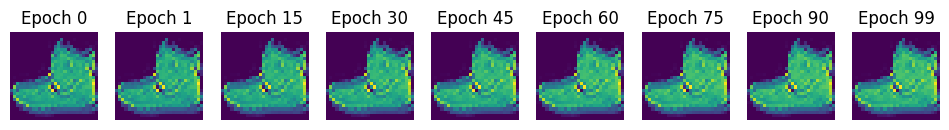

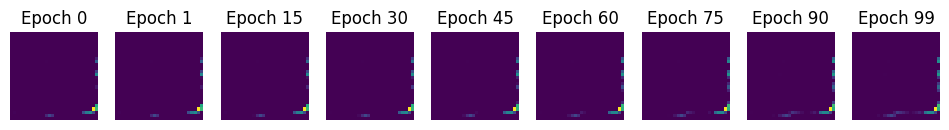

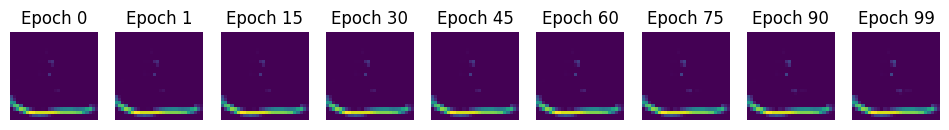

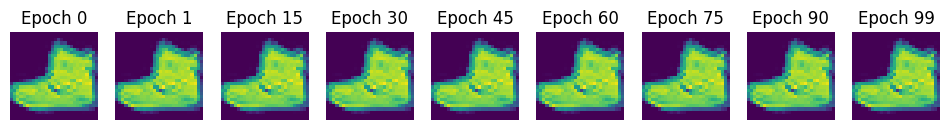

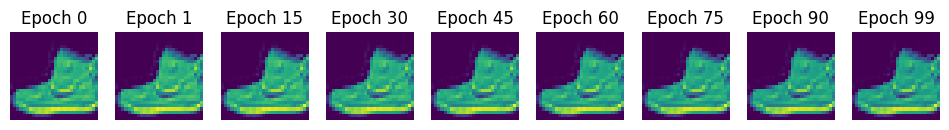

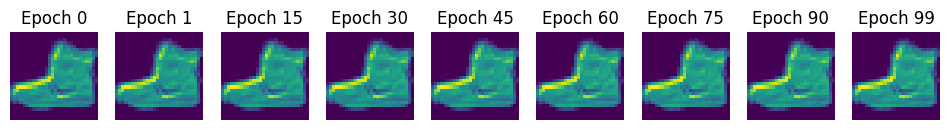

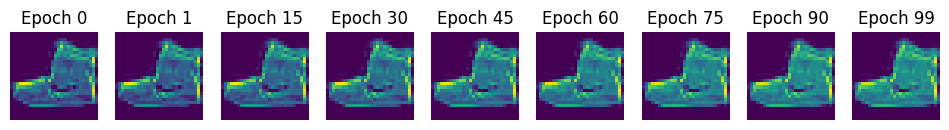

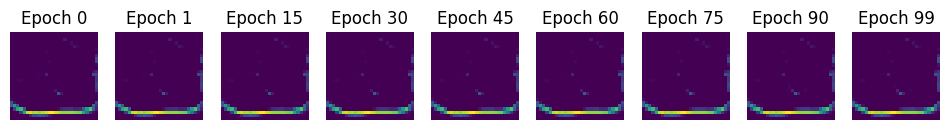

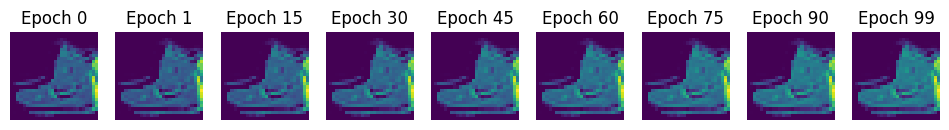

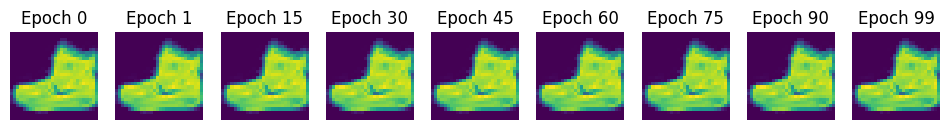

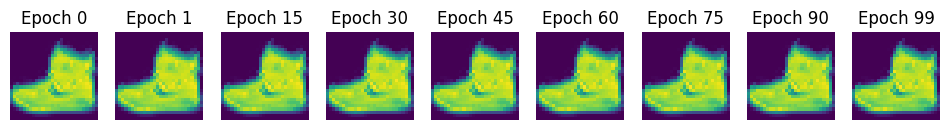

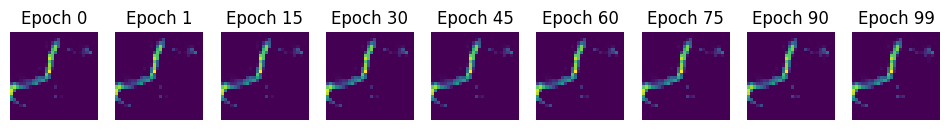

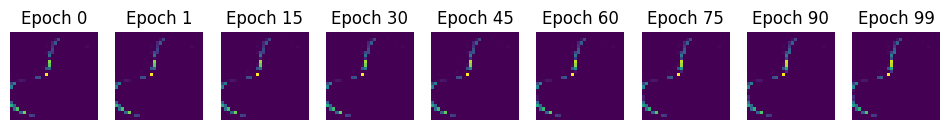

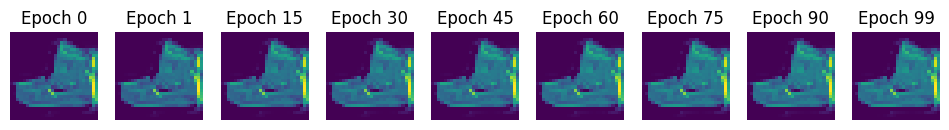

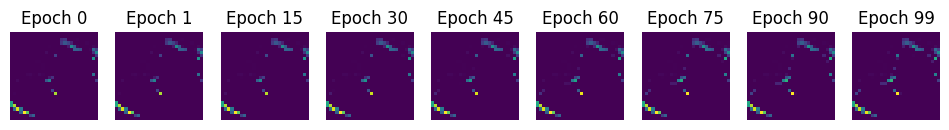

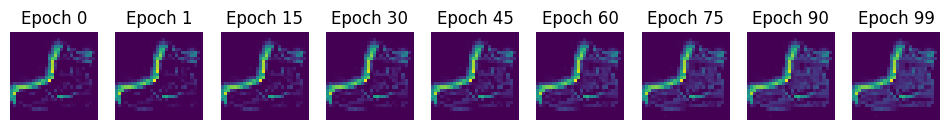

In [92]:
for i in range(16):
    filter_idx = i
    fig, axes = plt.subplots(1,len(epochs),figsize=(12,4))
    for ax, epoch in zip(axes, epochs):

        feature_map = feature_history[epoch]["maps"][0,filter_idx]

        ax.imshow(feature_map,cmap="viridis")
  
        ax.set_title(f"Epoch {epoch}")
        ax.axis("off")

    plt.show()

In [93]:
maps = feature_history[99]["pooled_maps"].squeeze(0)
# (16,14,14)

maps = maps.flatten(1)
#(16,196)

maps = F.normalize(maps, dim=1)

similarity_matrix = maps @ maps.T

mask = ~torch.eye(maps.size(0), dtype=torch.bool)

mean_similarity = similarity_matrix[mask].mean()
max_similarity = similarity_matrix[mask].max()

print(mean_similarity)
print(max_similarity)

tensor(0.4772)
tensor(0.9738)


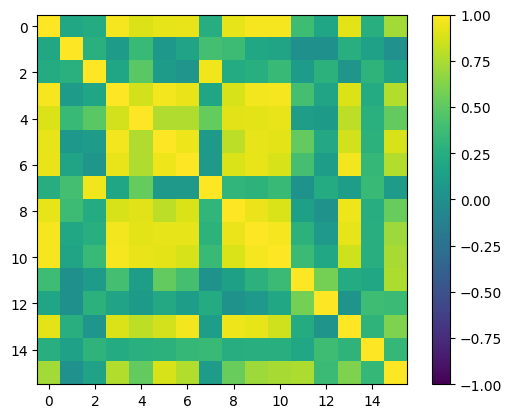

In [94]:
plt.imshow(similarity_matrix.detach().cpu(), vmin=-1, vmax=1)
plt.colorbar()

Text(0, 0.5, 'Number of filter pairs')

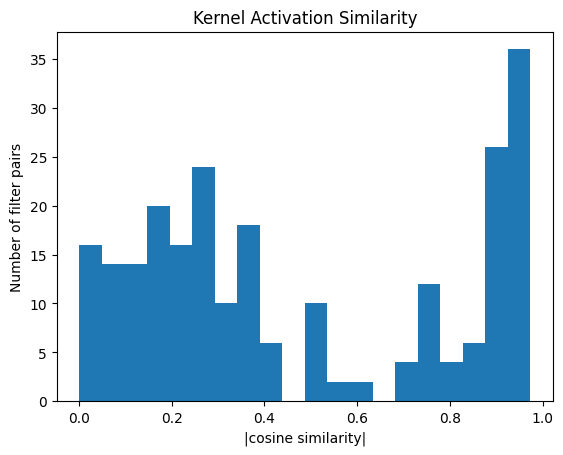

In [95]:
pairwise = similarity_matrix[mask].cpu().numpy()

plt.hist(pairwise, bins=20)
plt.title("Kernel Activation Similarity")
plt.xlabel("|cosine similarity|")
plt.ylabel("Number of filter pairs")